In this notebook we consider questions on the geogarphic distribution of subjects among the American fifty states. Our data set is drawn from the Mathematics Genealogy Project. 

1. We first need to assign a State to those dissertations that were granted in the United States, as this information is not in the original data set. 

In [180]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Load the CSV file into a structured DataFrame

df = pd.read_csv('/Users/jonathancohen1/Desktop/summer26/data/processed/version2_new_dataset_fitted.csv')

#Source : https://www.kaggle.com/datasets/mexwell/us-colleges-and-universities?resource=download
dg =pd.read_csv('/Users/jonathancohen1/Desktop/us-colleges-and-universities.csv', sep=';')

#keep only desired columns
df = df[['name', 'school', 'country', 'year', 'subject_code', 'subject_name', 'predicted_subject_code']]
dg = dg[['NAME', 'CITY', 'STATE']]

#Rename column to match df
dg = dg.rename(columns={'NAME': 'SCHOOL'})

#force school column to be string
df['school'] = df['school'].astype(str)


#from pathlib import Path
#print(Path.cwd())


In [ ]:
#found at https://medium.com/@jason_the_data_scientist/python-mapping-state-abbreviations-to-state-and-vice-versa-in-pandas-e4cd24edefb0

abbrev2state = {
        'AK': 'Alaska',
        'AL': 'Alabama',
        'AR': 'Arkansas',
        'AZ': 'Arizona',
        'CA': 'California',
        'CO': 'Colorado',
        'CT': 'Connecticut',
        'DC': 'District of Columbia',
        'DE': 'Delaware',
        'FL': 'Florida',
        'GA': 'Georgia',
        'HI': 'Hawaii',
        'IA': 'Iowa',
        'ID': 'Idaho',
        'IL': 'Illinois',
        'IN': 'Indiana',
        'KS': 'Kansas',
        'KY': 'Kentucky',
        'LA': 'Louisiana',
        'MA': 'Massachusetts',
        'MD': 'Maryland',
        'ME': 'Maine',
        'MI': 'Michigan',
        'MN': 'Minnesota',
        'MO': 'Missouri',
        'MS': 'Mississippi',
        'MT': 'Montana',
        'NC': 'North Carolina',
        'ND': 'North Dakota',
        'NE': 'Nebraska',
        'NH': 'New Hampshire',
        'NJ': 'New Jersey',
        'NM': 'New Mexico',
        'NV': 'Nevada',
        'NY': 'New York',
        'OH': 'Ohio',
        'OK': 'Oklahoma',
        'OR': 'Oregon',
        'PA': 'Pennsylvania',
        'RI': 'Rhode Island',
        'SC': 'South Carolina',
        'SD': 'South Dakota',
        'TN': 'Tennessee',
        'TX': 'Texas',
        'UT': 'Utah',
        'VA': 'Virginia',
        'VT': 'Vermont',
        'WA': 'Washington',
        'WI': 'Wisconsin',
        'WV': 'West Virginia',
        'WY': 'Wyoming',
        'PR': 'Puerto Rico',
        'VI': 'Virgin Islands'
    }

#Replace state abbreviations with full state names
dg['STATE'] = dg['STATE'].replace(abbrev2state)

#make all names upper case for ease
df["school_clean"] = (
    df["school"]
    .str.upper()
    .str.strip()
)

dg["school_clean"] = (
    dg["SCHOOL"]
    .str.upper()
    .str.strip()
)


#remove countries outside the US
df = df[df['country'] == 'UnitedStates']


#remove country column since now redundant
df = df.drop(columns=['country'])

#remove any rows with missing school
df = df[df['school'].notnull()]



#need replace some errors in the school column! 



#replace empty entries in subject_code column with those from predicted_subject_code column
df.loc[df['subject_code'] == '', 'subject_code'] = df['predicted_subject_code']





#number of unique schools
#distinct_list = df['school'].unique().tolist()
#number of empty strings in the State column
#empty_string_count = (df['State'] == '').sum()
#print(empty_string_count)
#print(distinct_list)


df = df.merge(
    dg[["school_clean", "STATE"]],
    left_on="school_clean",
    right_on="school_clean",
    how="left"
)

df.rename(columns={"STATE": "state"}, inplace=True)


In [184]:
#%pip install rapidfuzz

from rapidfuzz import process, fuzz

school_lookup = dg.set_index("school_clean")["STATE"].to_dict()

def find_state(school):
    if pd.isna(school):
        return None

    match = process.extractOne(
        school,
        school_lookup.keys(),
        scorer=fuzz.token_sort_ratio
    )

    if match and match[1] >= 85:  # threshold
        return school_lookup[match[0]]

    return None

mask = df["state"].isna()

df.loc[mask, "state"] = (
    df.loc[mask, "school_clean"]
      .apply(find_state)
)

In [185]:
#adding in missing values that the above did not catch

df.loc[df['school_clean'] == 'CITY UNIVERSITY OF NEW YORK', 'state'] = 'New York'
df.loc[df['school_clean'] == 'COLUMBIA UNIVERSITY', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT BUFFALO', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT BINGHAMTON', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT ALBANY', 'state'] = 'New York'
df.loc[df['school_clean'] == 'STATE UNIVERSITY OF NEW YORK AT STONY BROOK', 'state'] = 'New York'
df.loc[df['school_clean'] == 'COLLEGE OF WILLIAM AND MARY', 'state'] = 'Virginia'
df.loc[df['school_clean'] == 'UNIVERSITY OF MARYLAND COLLEGE PARK', 'state'] = 'Maryland'
df.loc[df['school_clean'] == 'UNIVERSITY OF MASSACHUSETTS AMHERST', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF MASSACHUSETTS, DARTMOUTH', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF MASSACHUSETTS LOWELL', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'RADCLIFFE COLLEGE', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF PITTSBURGH', 'state'] = 'Pennsylvania'
df.loc[df['school_clean'] == 'UNIVERSITY OF TENNESSEE - KNOXVILLE', 'state'] = 'Tennessee'
df.loc[df['school_clean'] == 'UNIVERSITY OF MISSOURI - COLUMBIA', 'state'] = 'Missouri'
df.loc[df['school_clean'] == 'UNIVERSITY OF MISSOURI - KANSAS CITY', 'state'] = 'Missouri'
df.loc[df['school_clean'] == 'SOUTHERN ILLINOIS UNIVERSITY AT CARBONDALE', 'state'] = 'Illinois'
df.loc[df['school_clean'] == 'UNIVERSITY OF CALIFORNIA, SANTA CRUZ', 'state'] = 'California'
df.loc[df['school_clean'] == 'UNIVERSITY OF COLORADO AT DENVER', 'state'] = 'Colorado'
df.loc[df['school_clean'] == 'THE OHIO STATE UNIVERSITY', 'state'] = 'Ohio'
df.loc[df['school_clean'] == 'UNIVERSITY OF CINCINNATI', 'state'] = 'Ohio'
df.loc[df['school_clean'] == 'UNIVERSITY OF CALIFORNIA, BERKELEY', 'state'] = 'California'
df.loc[df['school_clean'] == 'UNIVERSITY OF ALABAMA-TUSCALOOSA', 'state'] = 'Alabama'
df.loc[df['school_clean'] == 'RUTGERS UNIVERSITY, NEWARK', 'state'] = 'New Jersey'
df.loc[df['school_clean'] == 'UNIVERSITY OF MEDICINE AND DENTISTRY OF NEW JERSEY', 'state'] = 'New Jersey'
df.loc[df['school_clean'] == 'THE UNIVERSITY OF NEW MEXICO', 'state'] = 'New Mexico'
df.loc[df['school_clean'] == 'UNIVERSITY OF MARYLAND COLLEGE P', 'state'] = 'Maryland'
df.loc[df['school_clean'] == 'RUTGERS UNIVERSITY, NEW BRUNSW', 'state'] = 'New Jersey'
df.loc[df['school_clean'] == 'THE UNIVERSITY OF NEW MEX', 'state'] = 'New Mexico'
df.loc[df['school_clean'] == 'POLYTECHNIC INSTITUTE OF NEW YORK UNIVERSITY', 'state'] = 'New York'
df.loc[df['school_clean'] == 'MASSACHUSETTS INSTITUTE OF TECHNOLOGY/WOODS HOLE OCEANOGRAPHIC INSTITUTION', 'state'] = 'Massachusetts'
df.loc[df['school_clean'] == 'UNIVERSITY OF PUERTO RICO AT MAYAGUEZ', 'state'] = 'Puerto Rico'
df.loc[df['school_clean'] == 'OREGON GRADUATE INSTITUTE OF SCIENCE & TECHNOLOGY', 'state'] = 'Oregon'
df.loc[df['school_clean'] == 'CLAREMONT GRADUATE UNIVERSITY AND SAN DIEGO STATE UNIVERSITY', 'state'] = 'California'
df.loc[df['school_clean'] == 'NEW SCHOOL FOR SOCIAL RESEARCH', 'state'] = 'New York'
df.loc[df['school_clean'] == 'UNIVERSITY OF KANSAS SCHOOL OF BUSINESS', 'state'] = 'Kansas'
df.loc[df['school_clean'] == 'GEORGE PEABODY COLLEGE FOR TEACHERS', 'state'] = 'Tennessee'
df.loc[df['school_clean'] == 'INDIANA UNIVERSITY-PURDUE UNIVERSITY INDIANAPOLIS', 'state'] = 'Indiana'


#Note Polytechnic University does not uniquely specify a school

#how many empty or NaN values are in the state column
#empty_or_nan = (df['state'].isna() | (df['state'] == "")).sum()
#print(f"Number of empty or NaN values in 'state' column: {empty_or_nan}")

2. Having removed all data not associated with the US, and assigned States to those that remained, we initiate some EDA. 

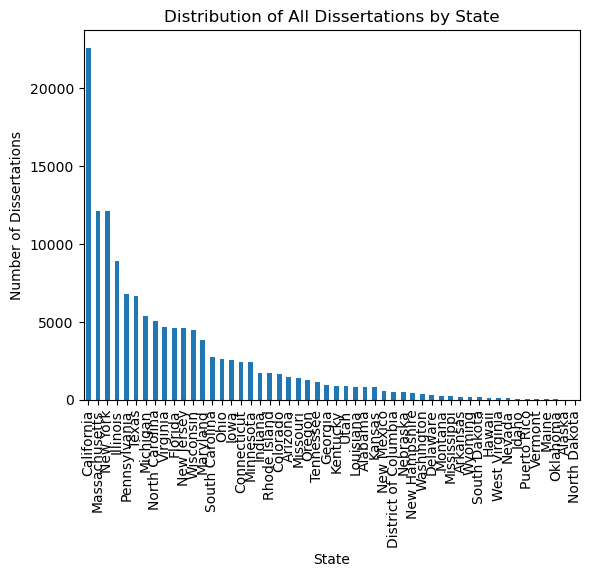

state
Alabama                   837
Alaska                      9
Arizona                  1446
Arkansas                  178
California              22600
Colorado                 1643
Connecticut              2452
Delaware                  331
District of Columbia      494
Florida                  4630
Georgia                   930
Hawaii                    116
Idaho                      73
Illinois                 8894
Indiana                  1728
Iowa                     2545
Kansas                    828
Kentucky                  905
Louisiana                 844
Maine                      44
Maryland                 3861
Massachusetts           12142
Michigan                 5347
Minnesota                2432
Mississippi               241
Missouri                 1418
Montana                   250
Nebraska                  493
Nevada                     91
New Hampshire             404
New Jersey               4610
New Mexico                574
New York                12126
Nort

In [235]:
#dictionary to look up subject names by code
subject_lookup = (
    df[['subject_code', 'subject_name']]
    .dropna()
    .drop_duplicates(subset='subject_code')
    .set_index('subject_code')['subject_name']
    .to_dict()
)

subject_name = subject_lookup.get(subject, f"Subject {subject}")


#make a histogram of the state columns
df['state'].value_counts().plot(kind='bar')
plt.title('Distribution of All Dissertations by State')
plt.xlabel('State')
plt.ylabel('Number of Dissertations')
plt.show()

#Note some (but not all) of this imbalance may be an artifact of the data entry, rather than the prevalence of schools in each state


# list the number of names from each state
name_counts = df.groupby('state').size()
print(name_counts)

#list as ratio
ratio = name_counts/name_counts.sum()
print(ratio)

#order the states by the number of names
ordered_name_counts = name_counts.sort_values(ascending=False)
print(ordered_name_counts)



In [187]:
# #In df find the number of entries per year
# #x=df.groupby('year').size()

# #for year, count in x.items():
# #    print(f"Year {year}: {count} entries")

# #in 1929 is first year with 100 entries

# #omit all years before 1929
# df_filtered = df[df['year'] >= 1929]

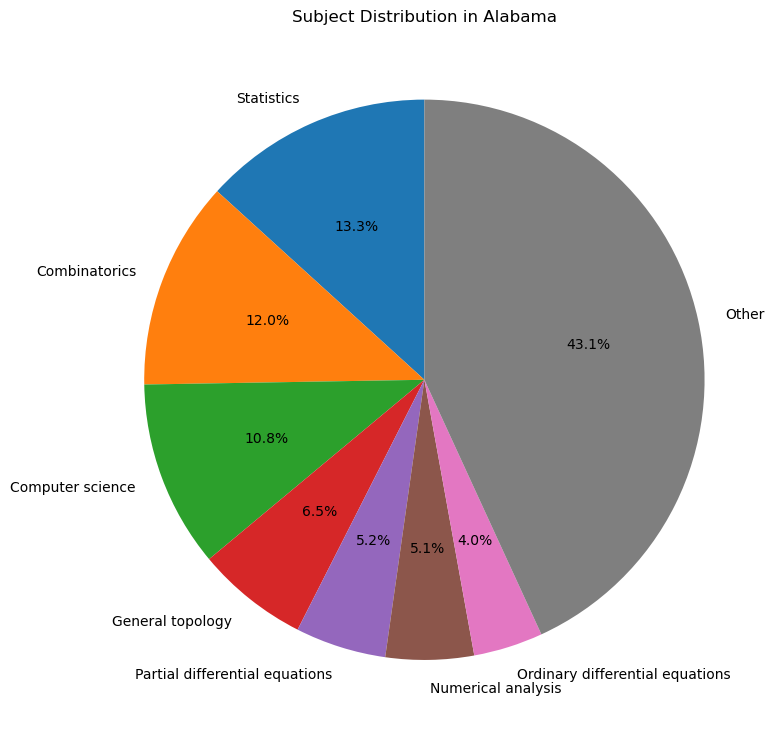

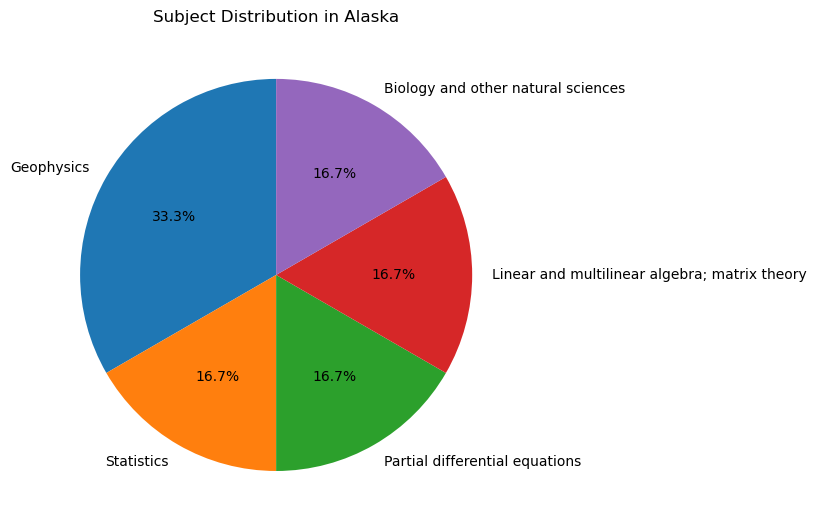

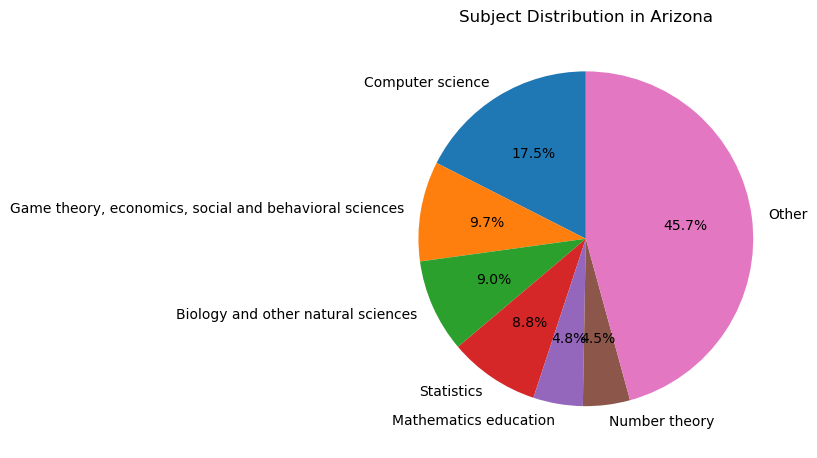

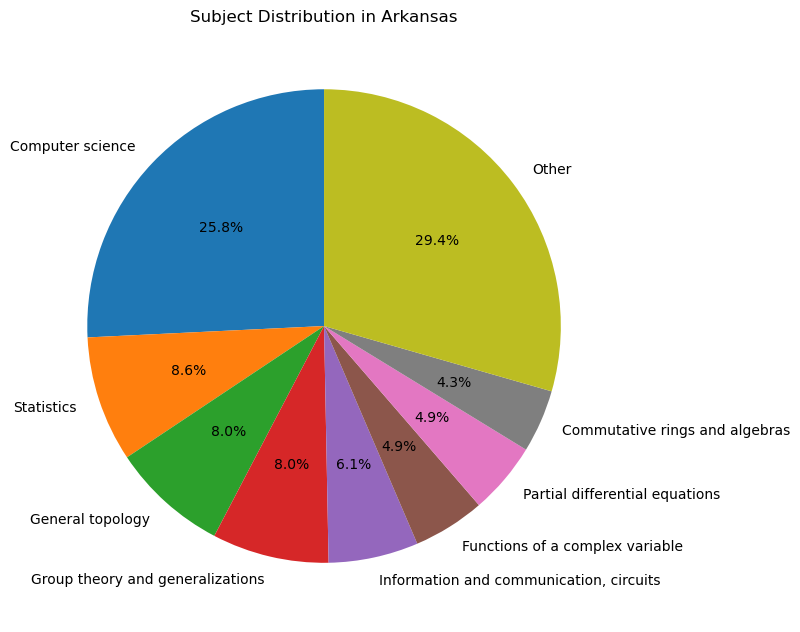

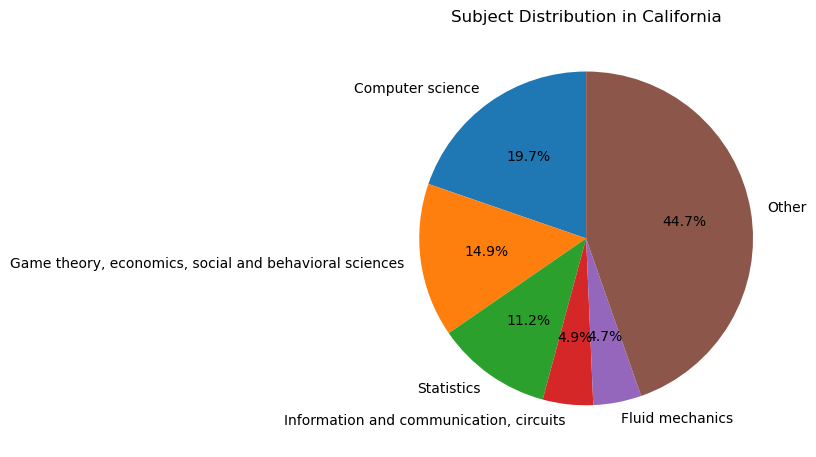

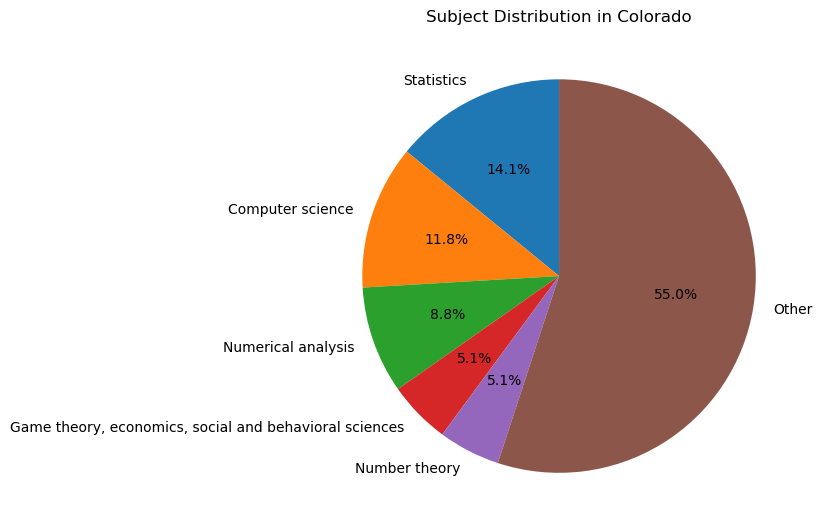

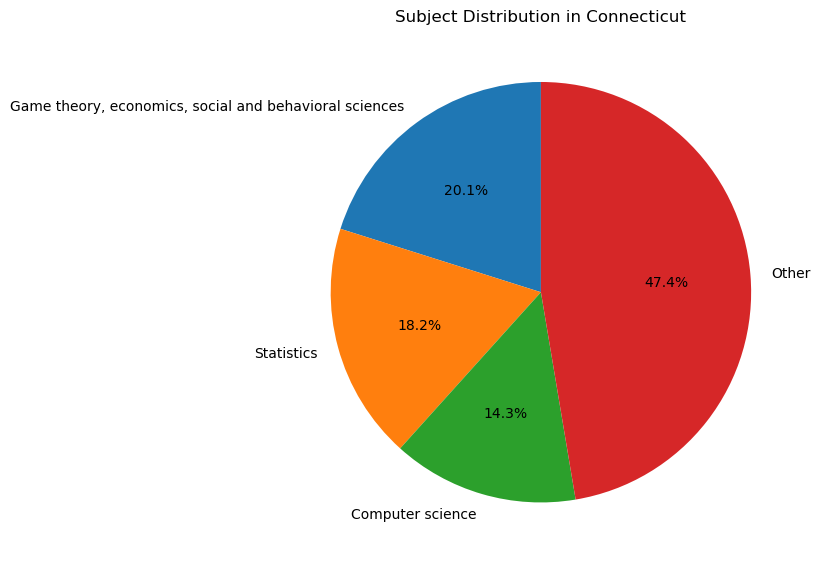

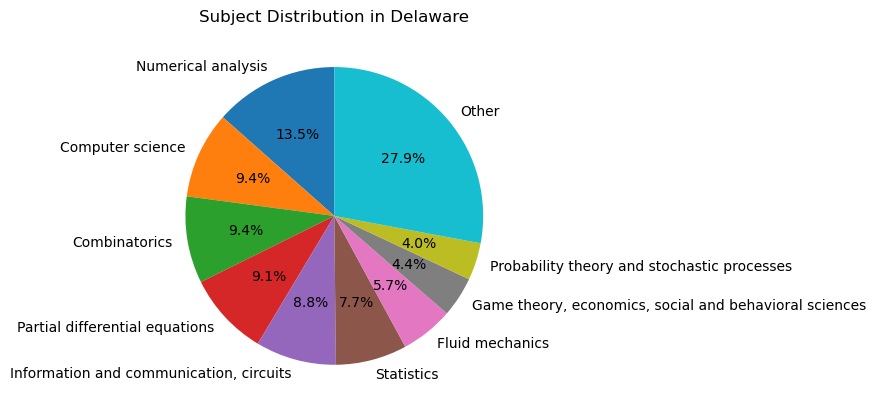

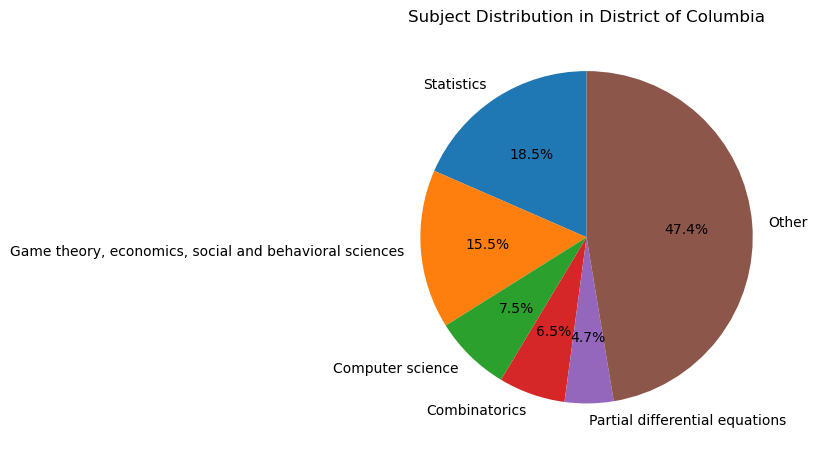

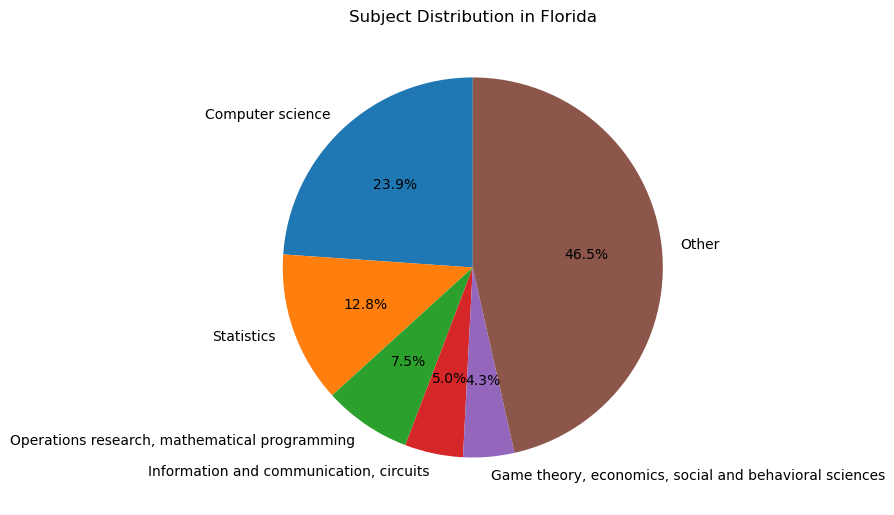

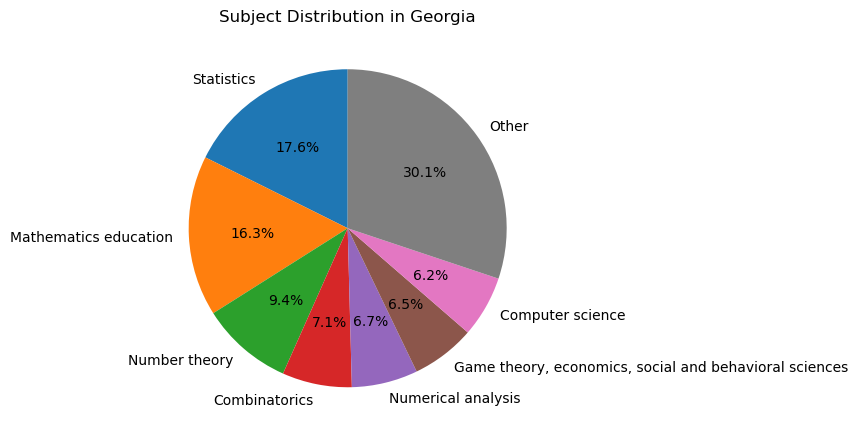

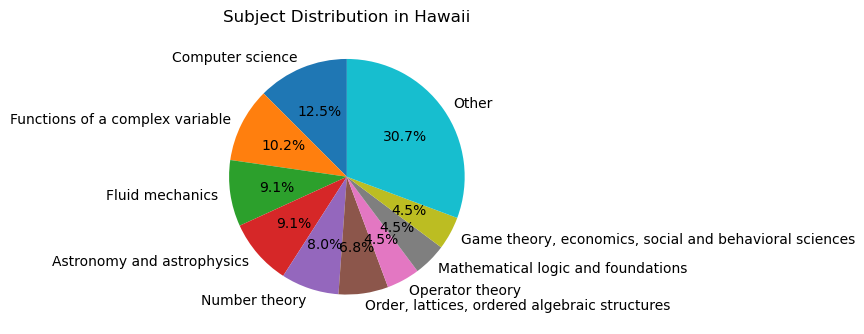

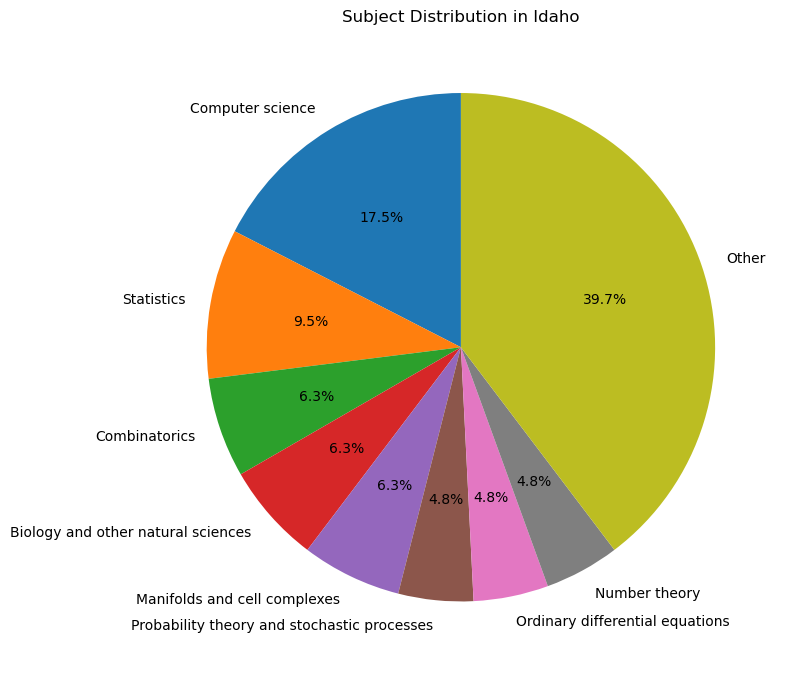

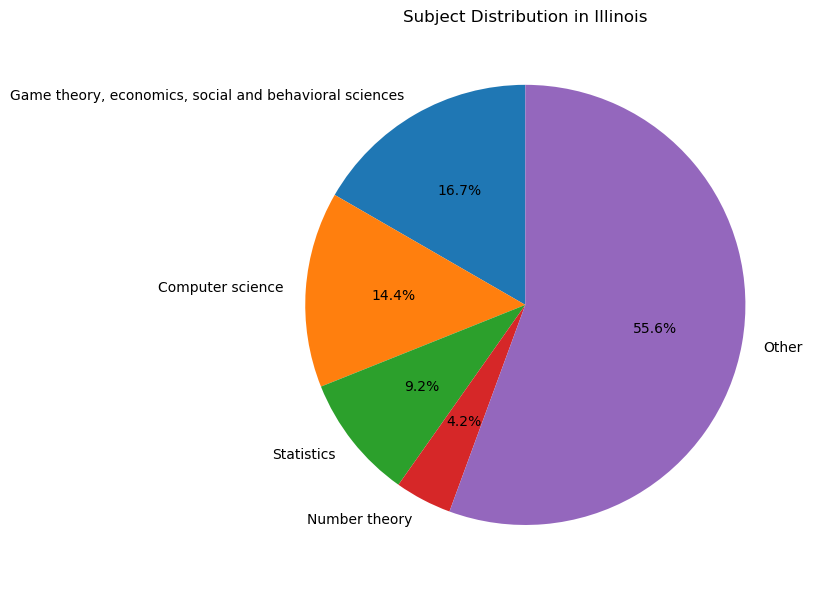

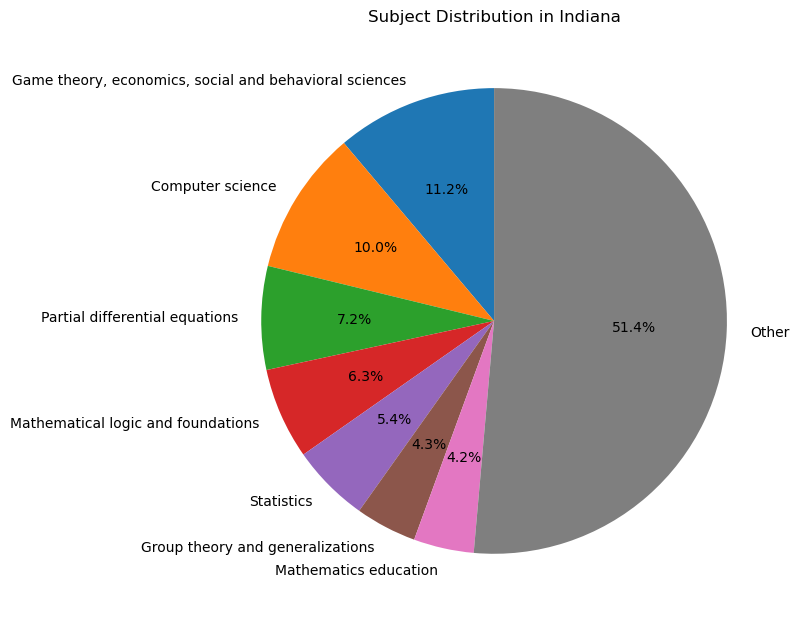

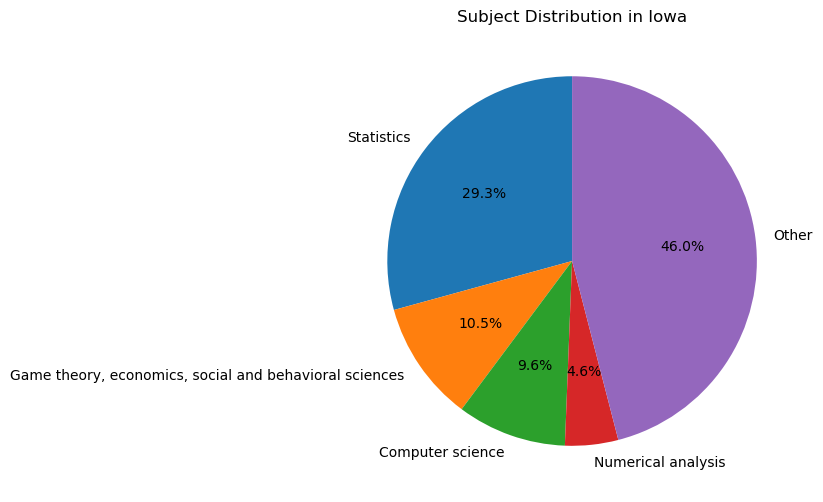

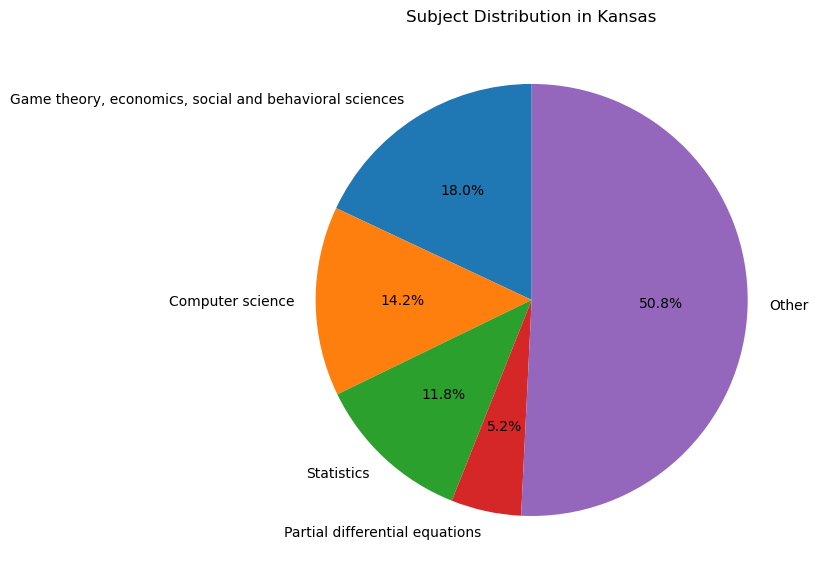

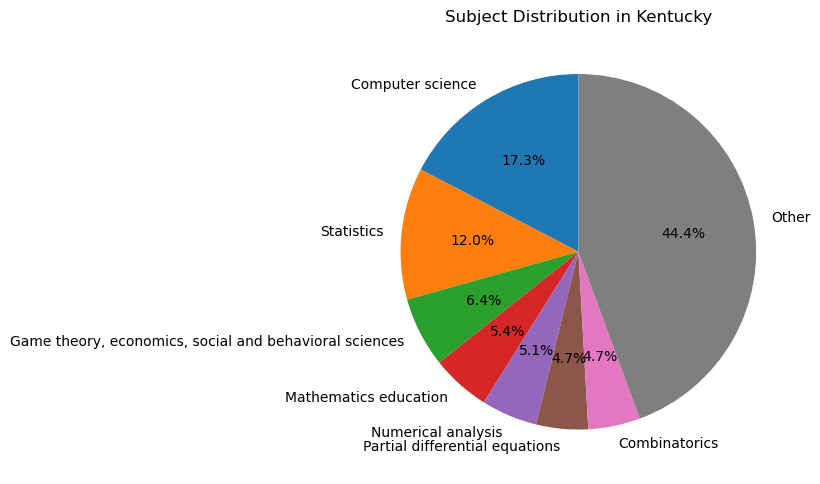

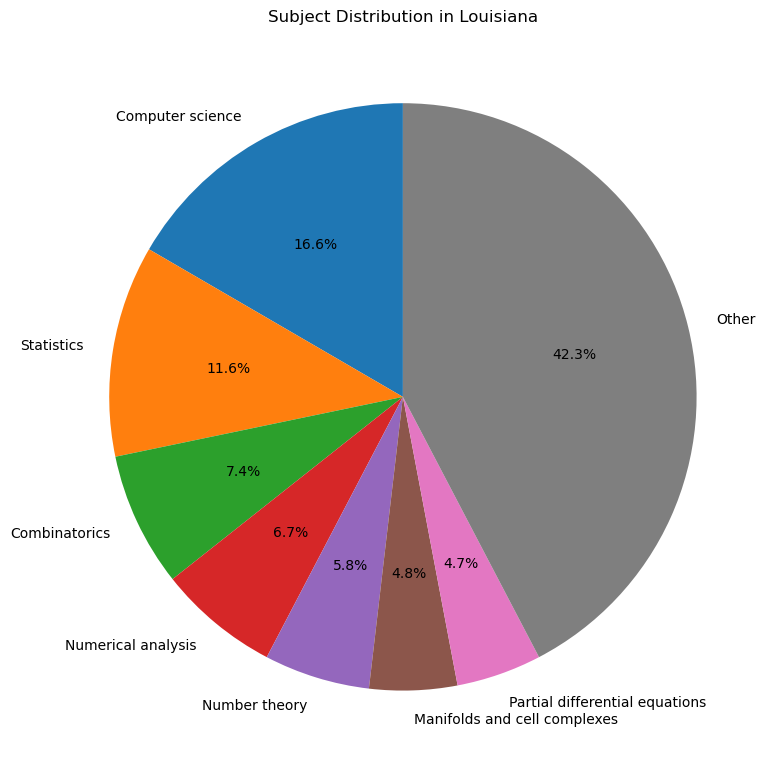

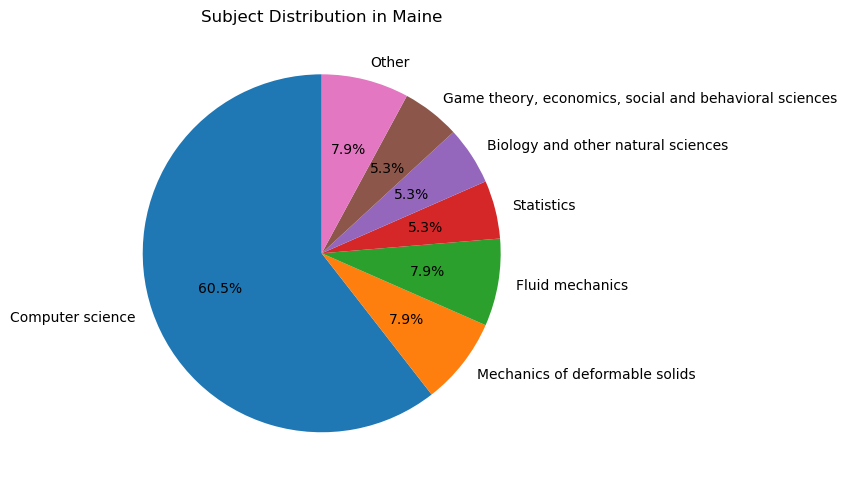

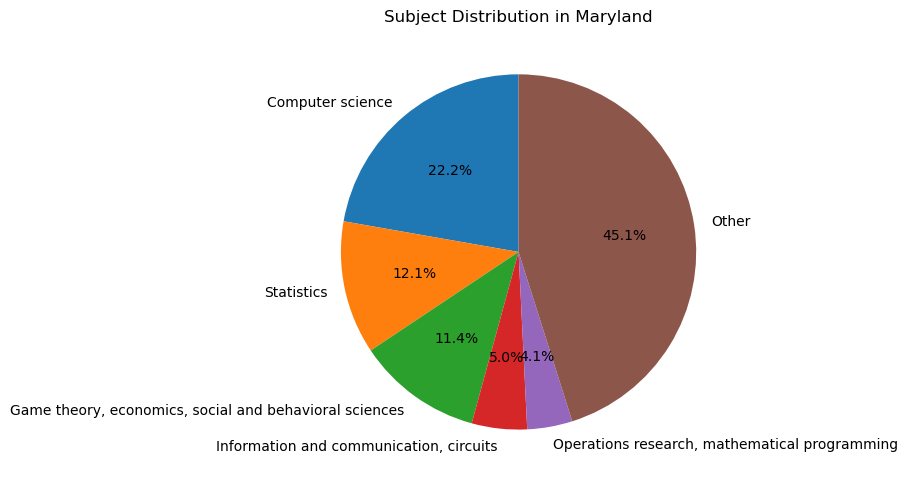

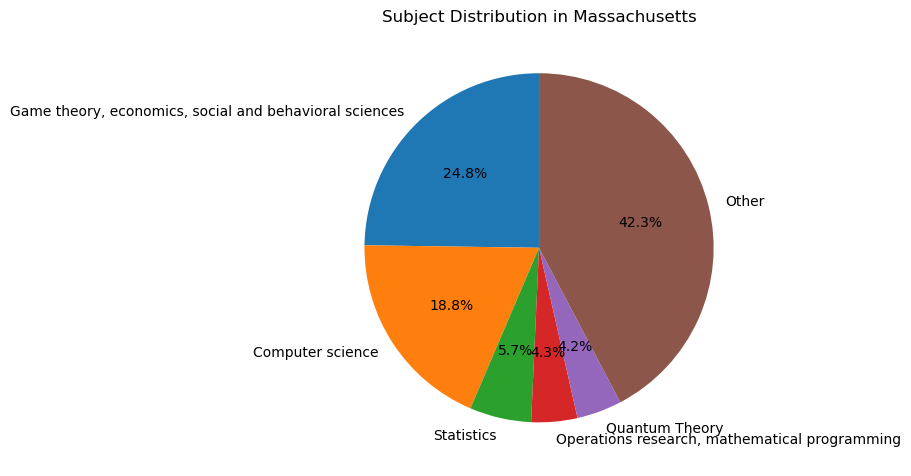

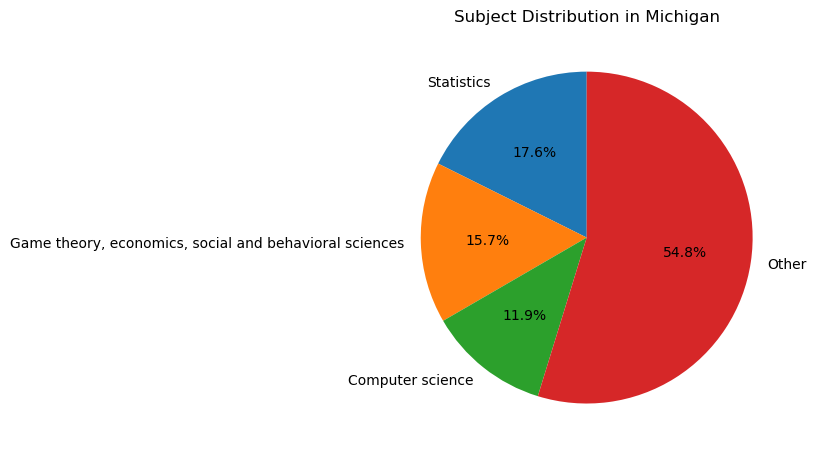

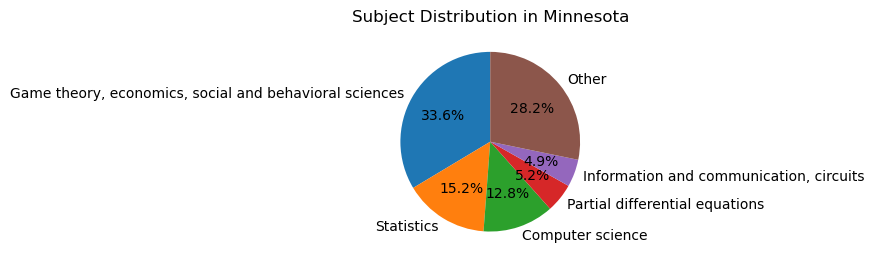

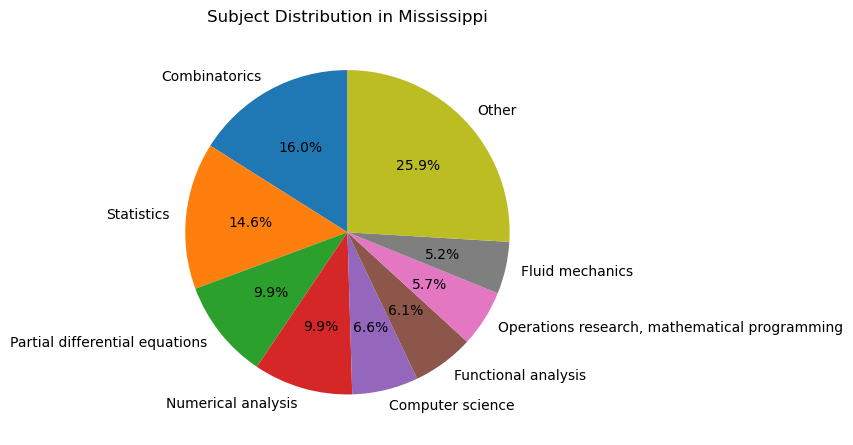

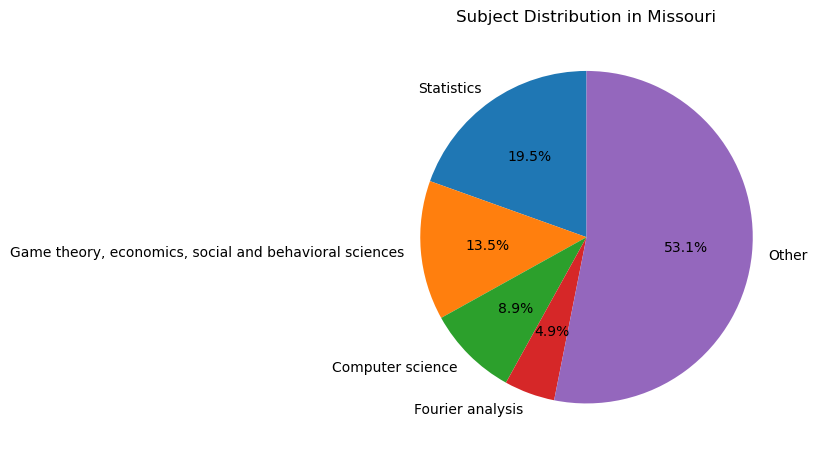

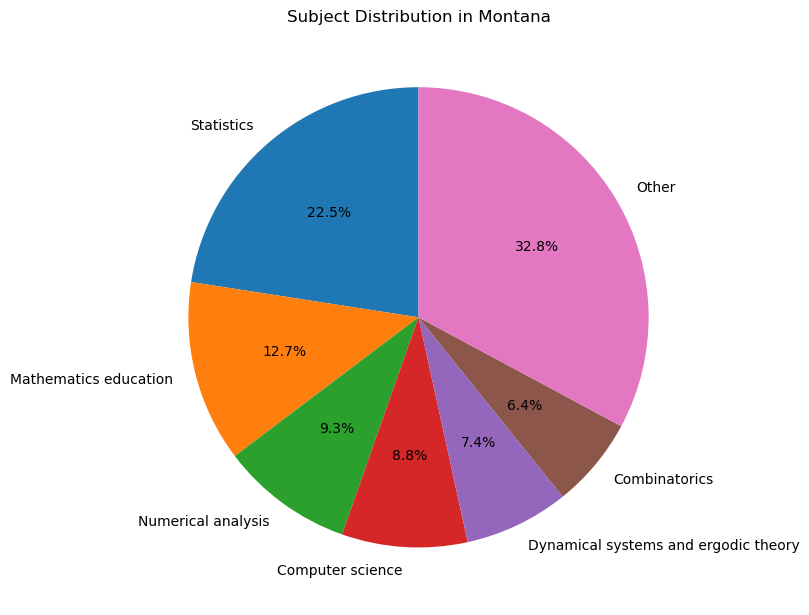

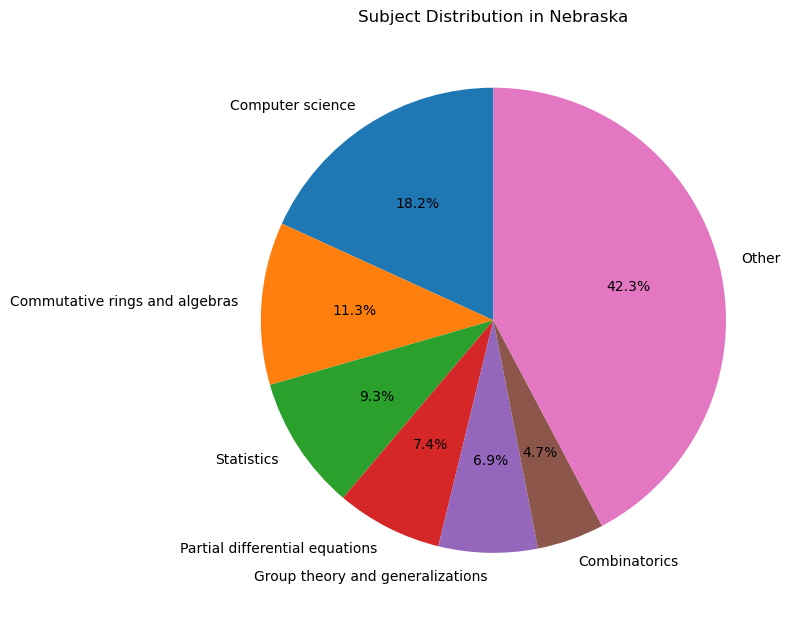

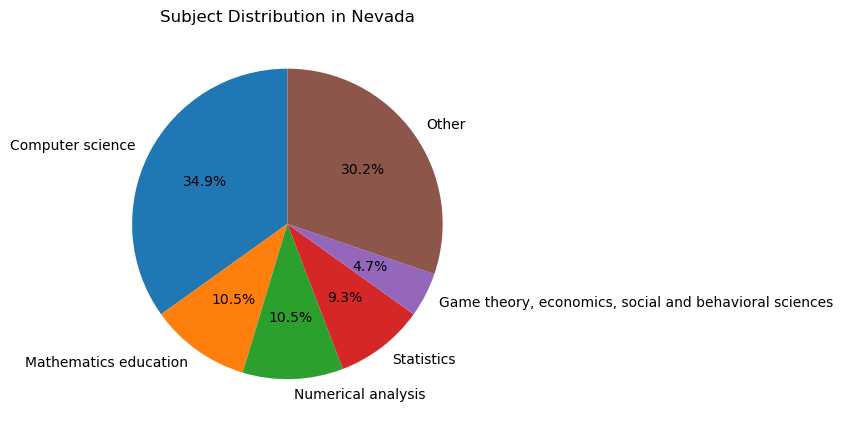

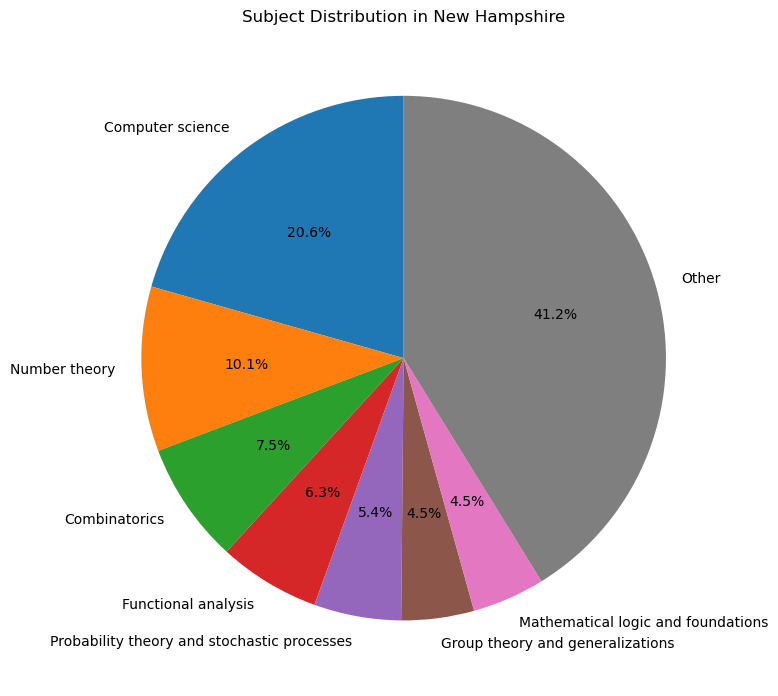

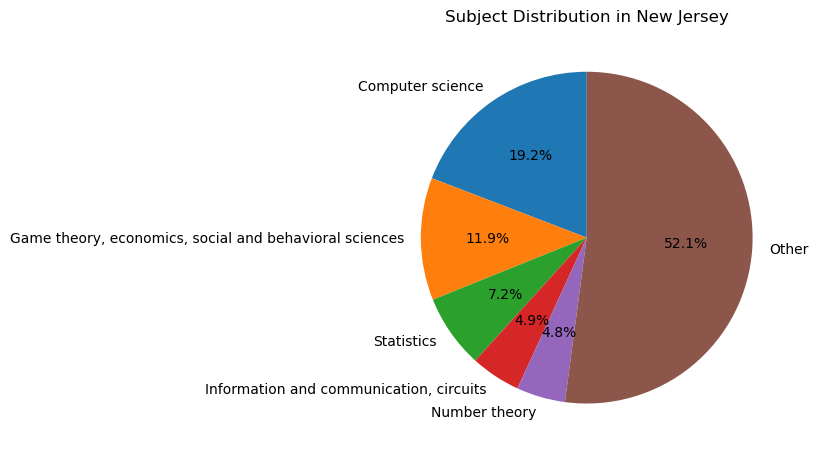

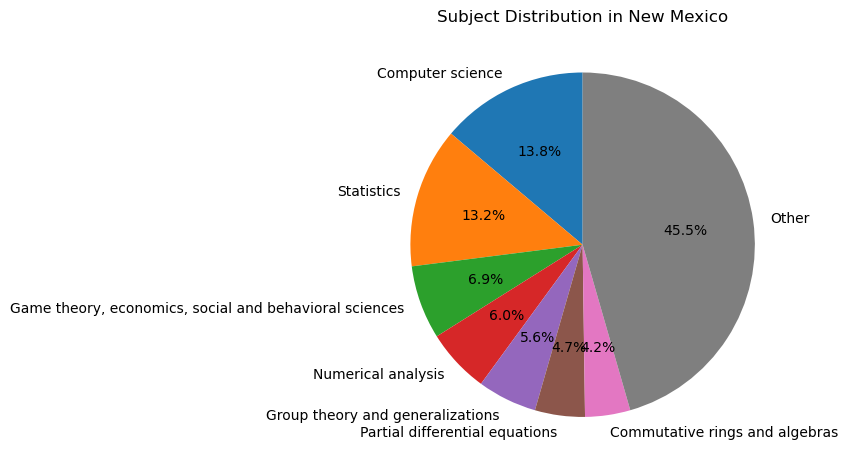

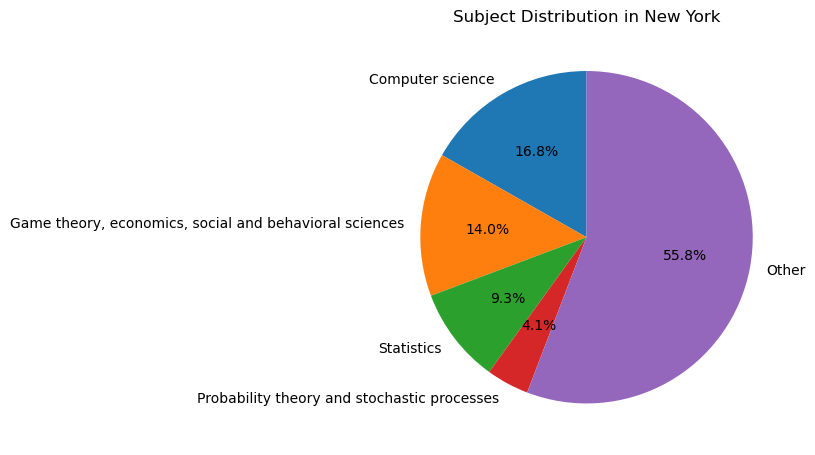

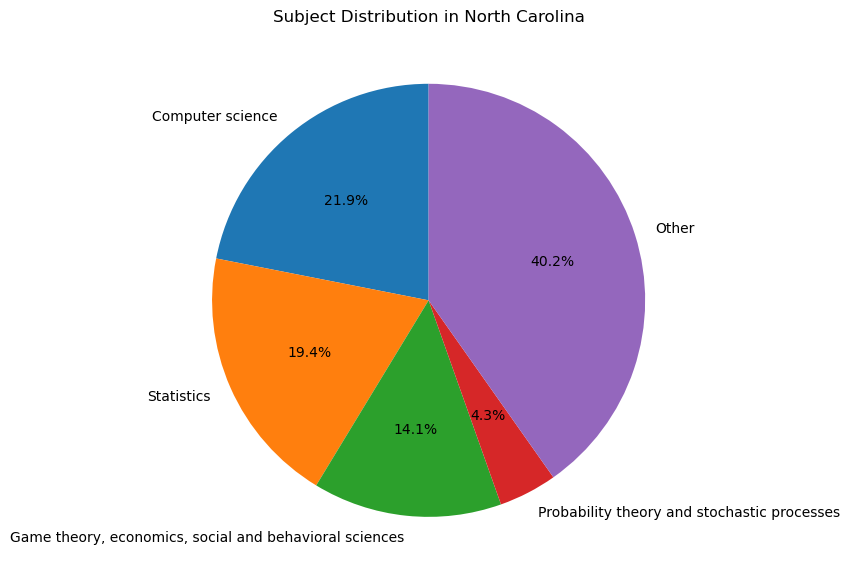

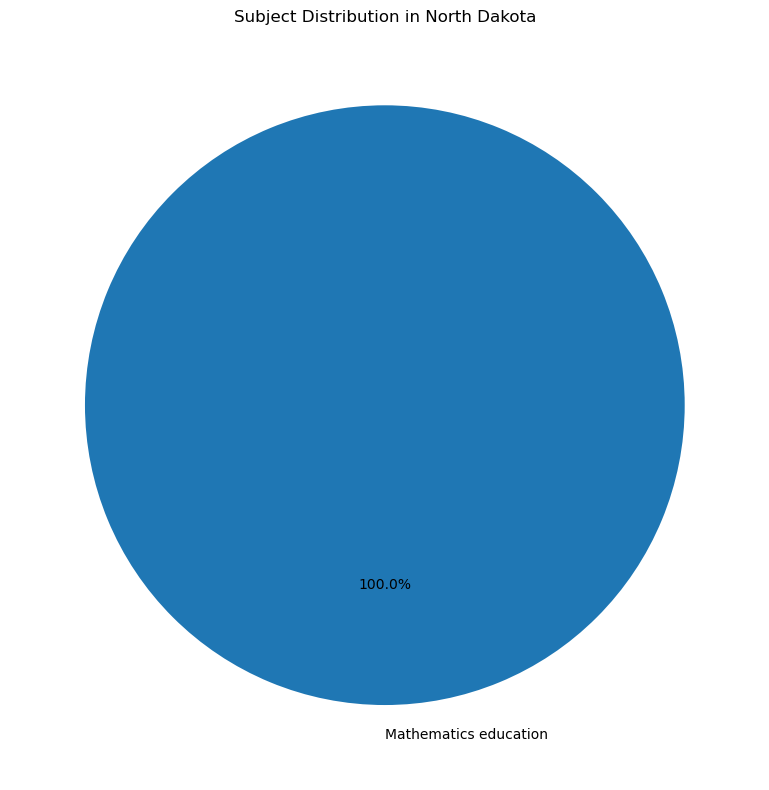

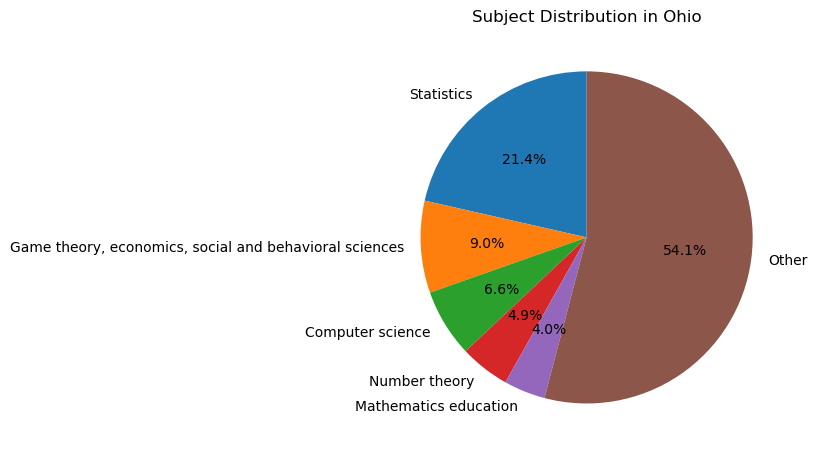

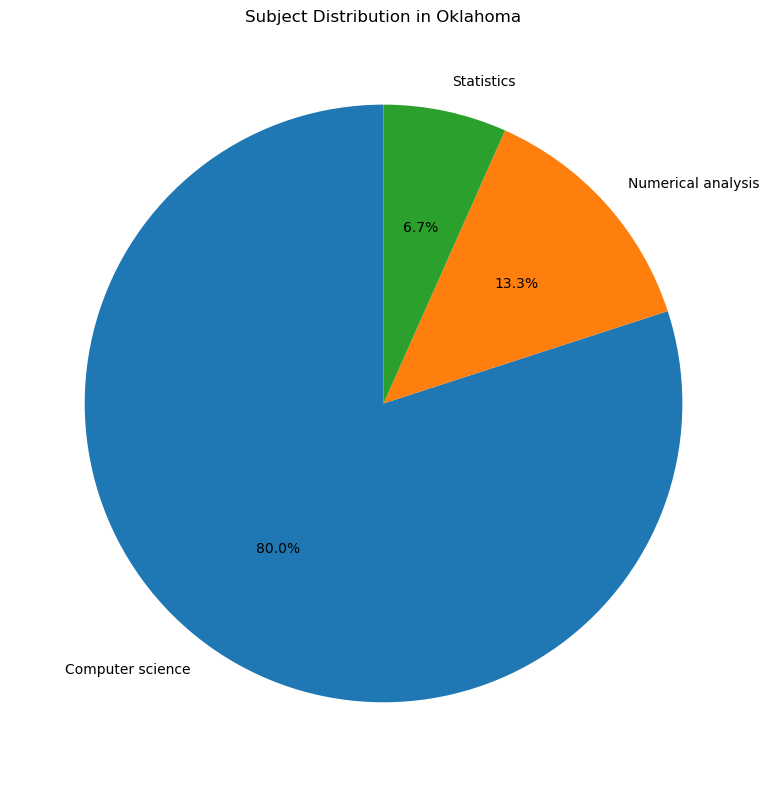

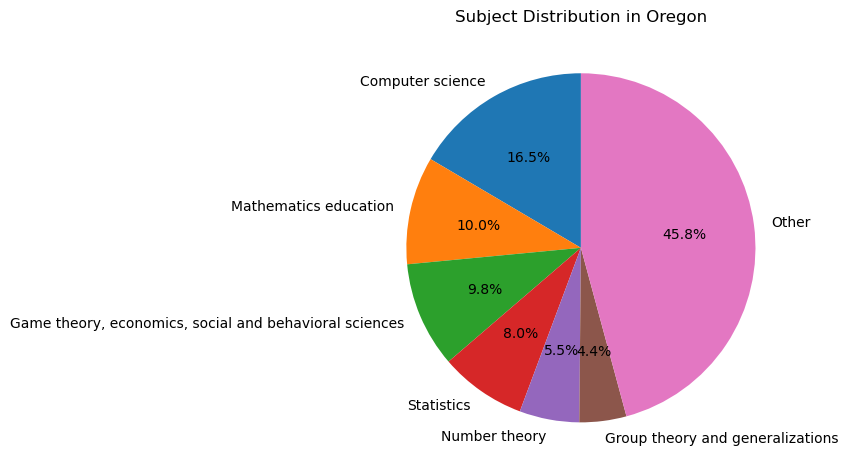

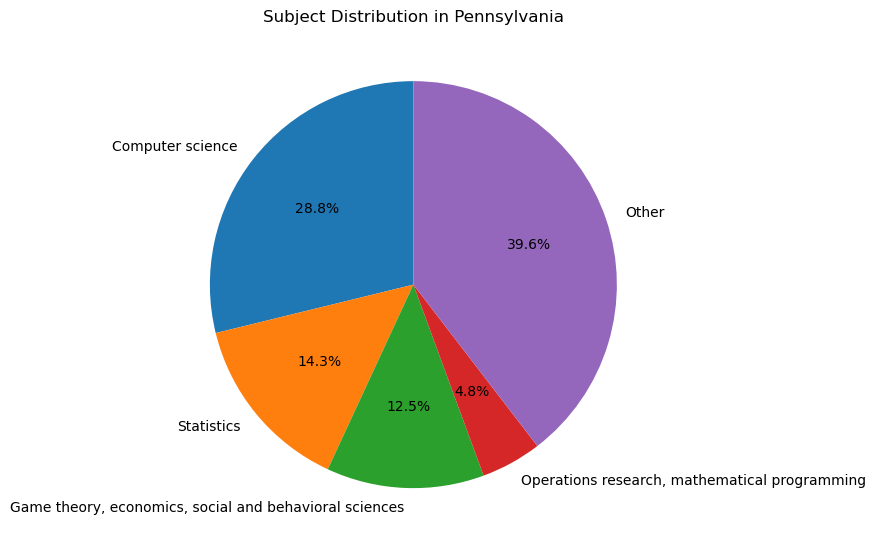

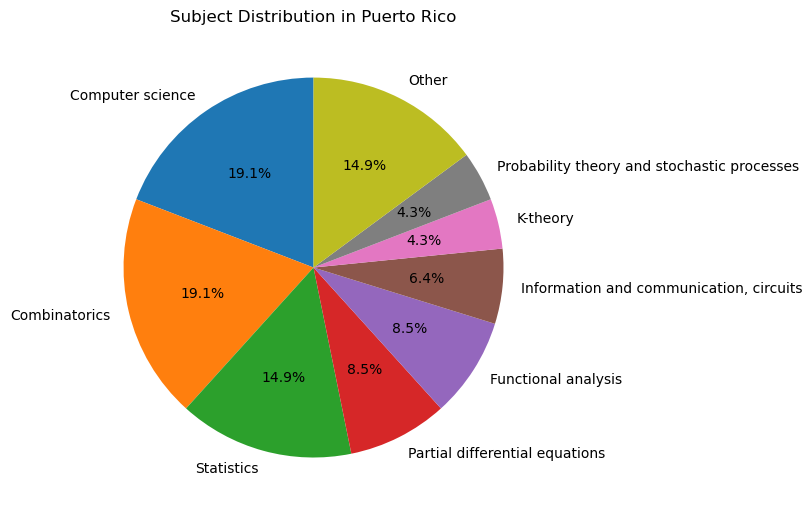

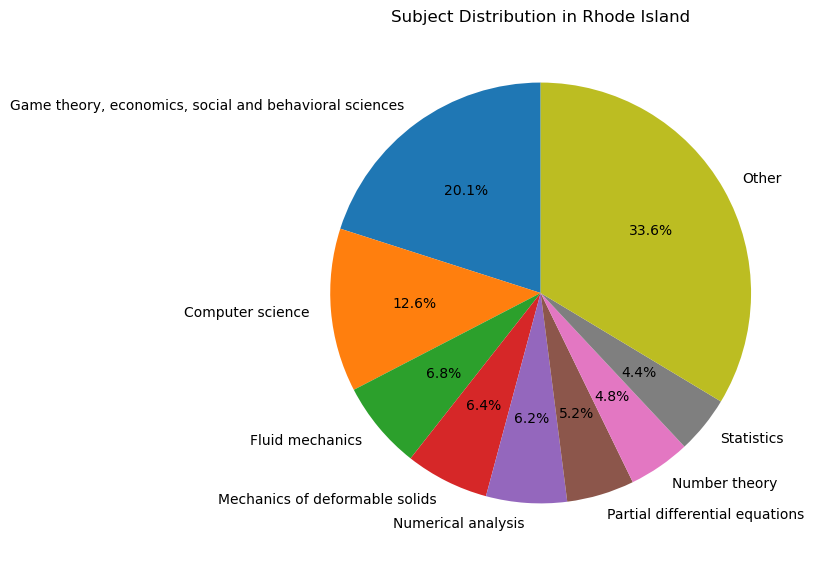

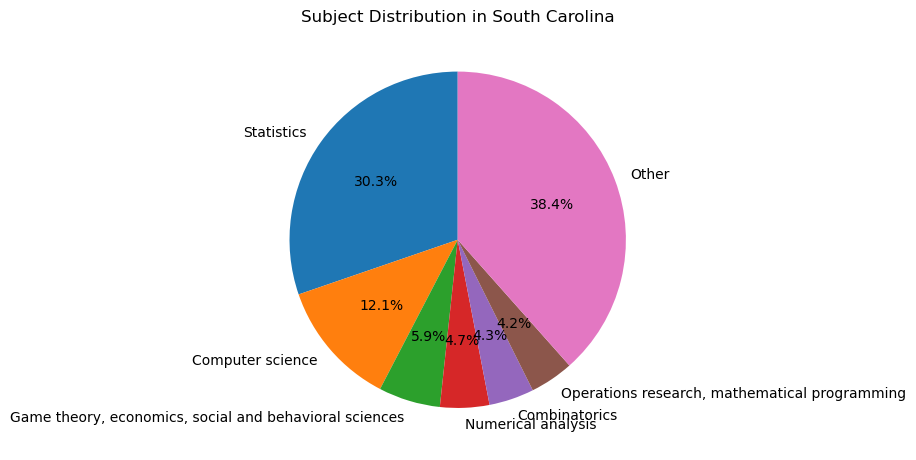

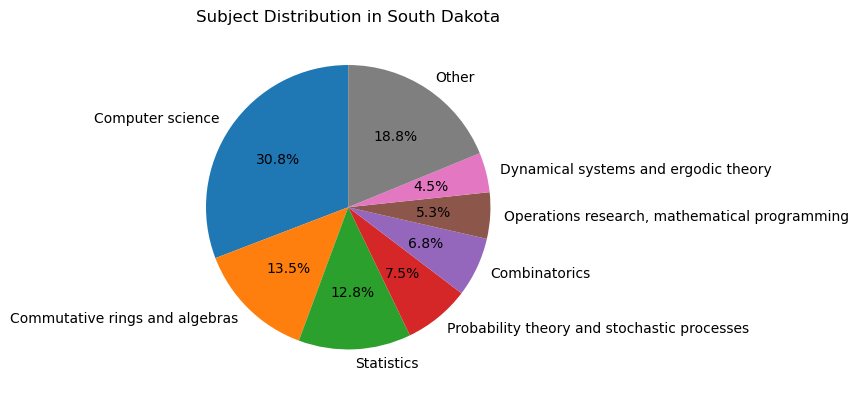

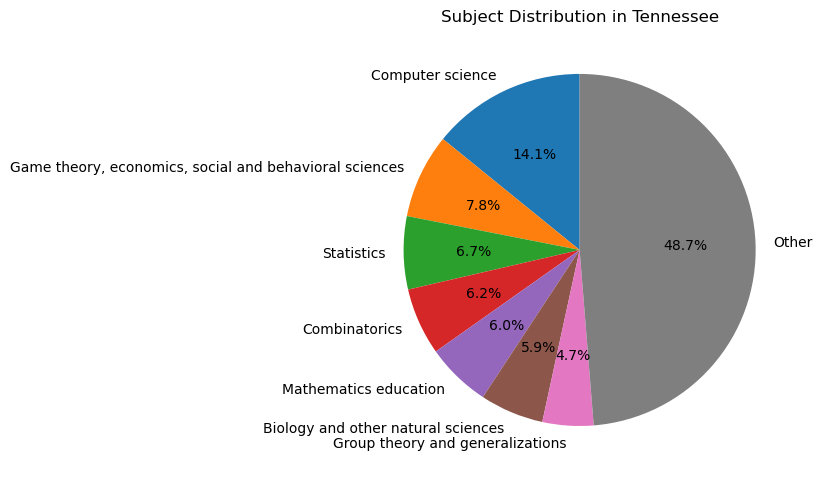

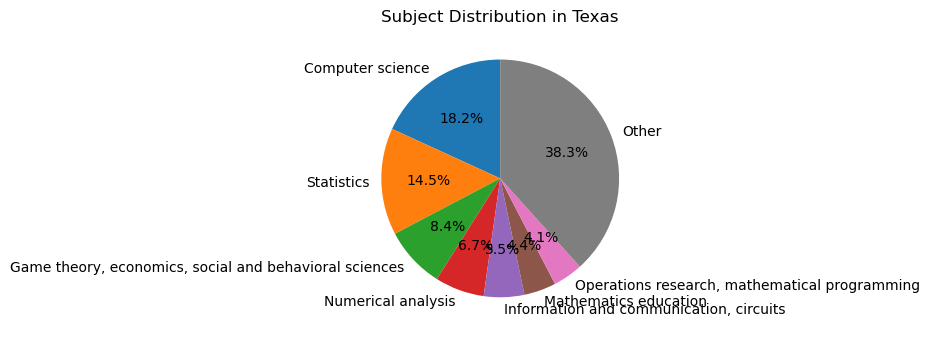

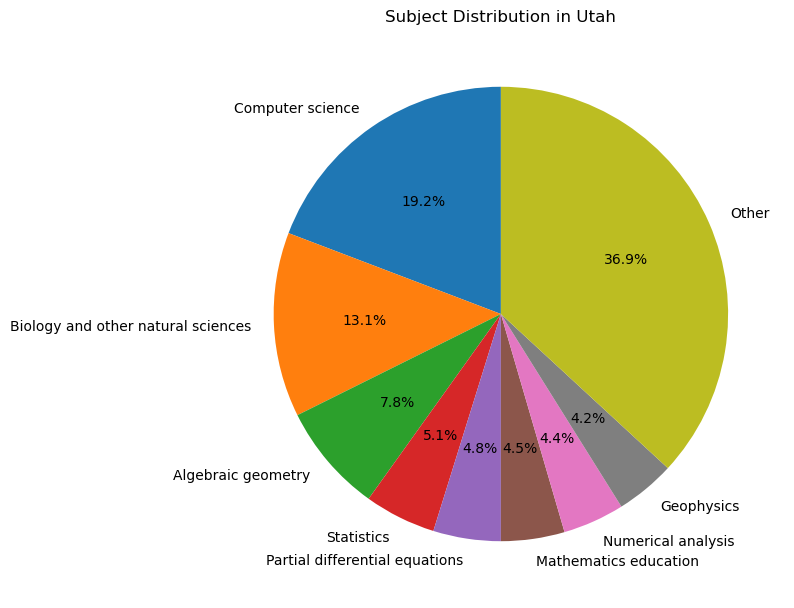

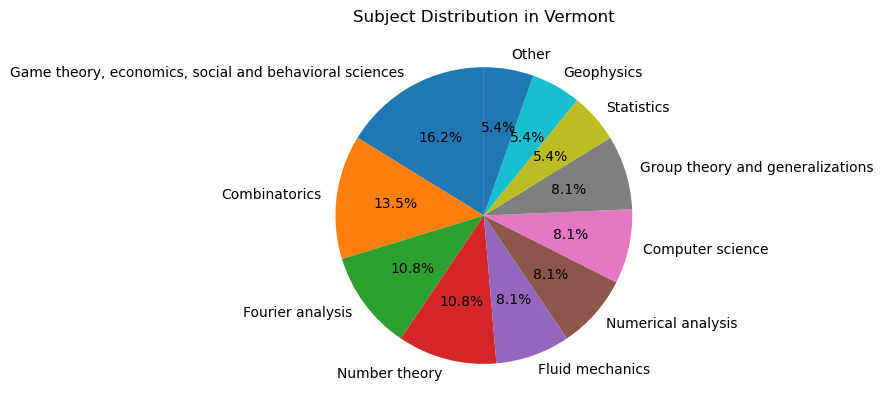

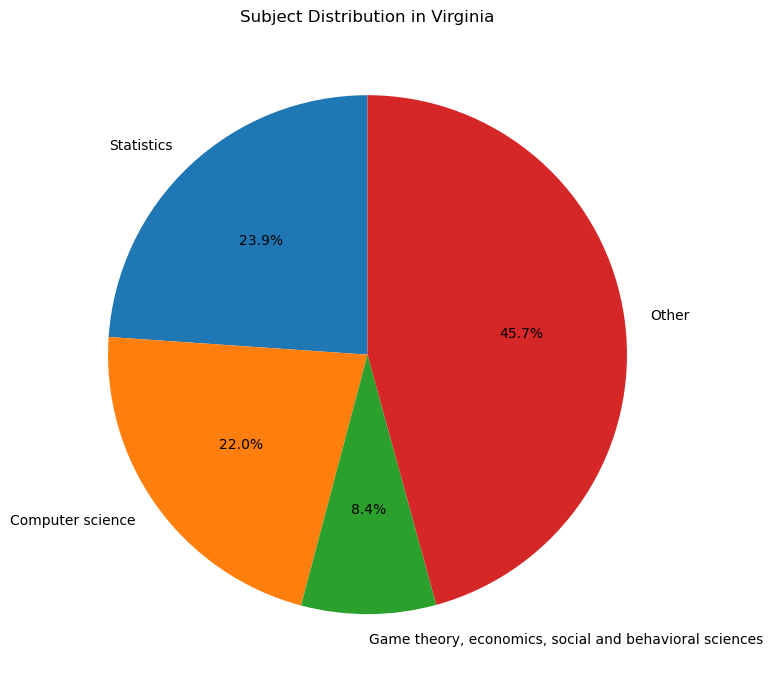

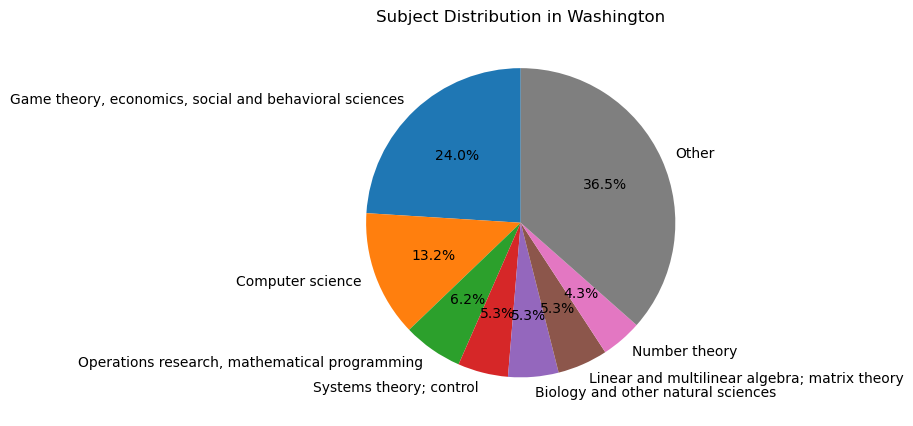

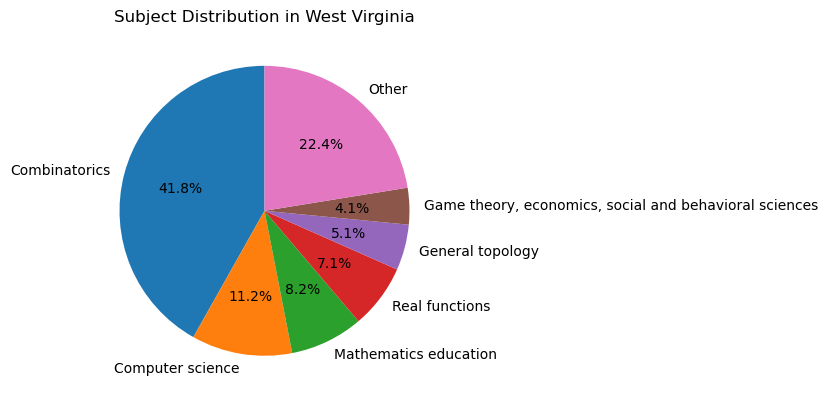

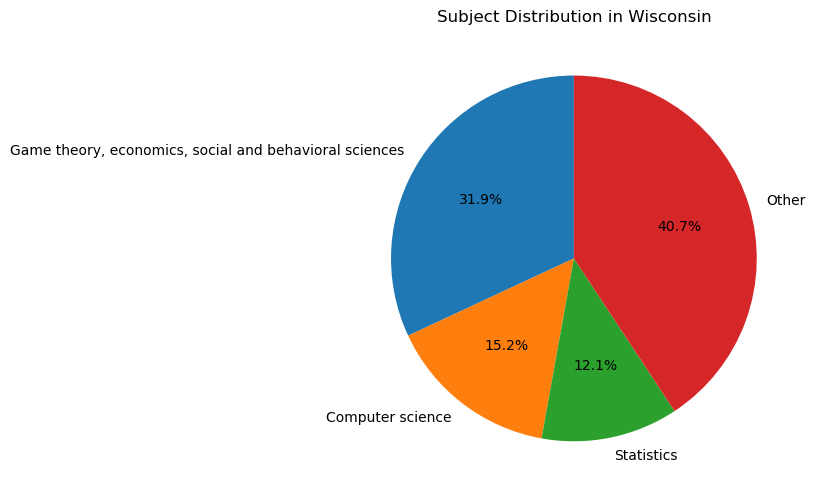

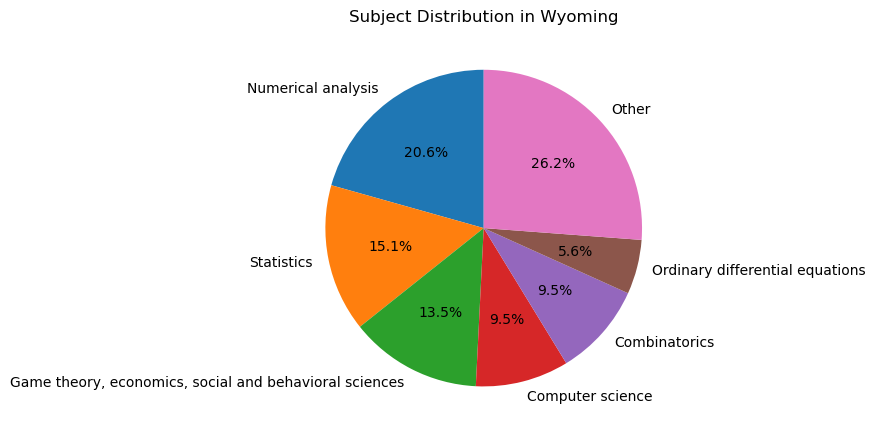

In [245]:
#pie chart for each state showing how popular subjects are


#want to group together all subjects that are less than 3% of the total for each state into an "Other" category


# def group_small_categories(series, threshold=0.04):
#     """
#     Groups categories representing less than `threshold`
#     of the total into a single 'Other' category.
#     """
#     proportions = series / series.sum()
#     small = proportions < threshold

#     return pd.concat([
#         series[~small],
#         pd.Series({"Other": series[small].sum()})
#     ])


# counts = df["subject_name"].value_counts()

# counts = group_small_categories(counts, threshold=0.04)

# plt.pie(
#     counts,
#     labels=counts.index,
#     autopct="%1.1f%%",
#     startangle=90
# )
# plt.show()

# for state in df['state'].unique():
#     state_df = df[df['state'] == state]
#     subjectcounts = state_df['subject_code'].value_counts()
#     plt.figure(figsize=(10, 8))
#     plt.pie(state_df['subject_code'].value_counts(), labels=state_df['subject_code'].value_counts().index, autopct='%1.1f%%')
#     plt.title(f"Subject Popularity in {state}")
#     plt.show()


import matplotlib.pyplot as plt
import pandas as pd

threshold = 0.04  # 3%

for state in sorted(df["state"].dropna().unique()):

    # Data for one state
    state_df = df[df["state"] == state]

    # Count subjects
    counts = state_df["subject_name"].value_counts()

    # Compute proportions
    proportions = counts / counts.sum()

    # Group small categories
    grouped_counts = pd.concat([
        counts[proportions >= threshold],
        pd.Series({"Other": counts[proportions < threshold].sum()})
    ])

    # Remove "Other" if nothing was grouped
    grouped_counts = grouped_counts[grouped_counts > 0]

    # Plot
    plt.figure(figsize=(8,8))

    plt.pie(
        grouped_counts,
        labels=grouped_counts.index,
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title(f"Subject Distribution in {state}")

    plt.tight_layout()
    plt.show()

    

In [ ]:
# Count dissertations by state/year/subject
counts = (
    df.groupby(['state', 'year', 'subject_code'])
      .size()
      .reset_index(name='count')
)

# Total dissertations per state/year
totals = (
    counts.groupby(['state', 'year'])['count']
          .sum()
          .reset_index(name='total')
)

counts = counts.merge(totals, on=['state', 'year'])

counts['proportion'] = counts['count'] / counts['total']

print(counts)



         state    year  subject_code  count  total  proportion
0      Alabama  1927.0          91.0      1      1         1.0
1      Alabama  1955.0          35.0      1      1         1.0
2      Alabama  1958.0          65.0      1      1         1.0
3      Alabama  1959.0          47.0      1      1         1.0
4      Alabama  1960.0          34.0      1      2         0.5
...        ...     ...           ...    ...    ...         ...
37683  Wyoming  2019.0          34.0      1      1         1.0
37684  Wyoming  2020.0           5.0      1      2         0.5
37685  Wyoming  2020.0          15.0      1      2         0.5
37686  Wyoming  2022.0          65.0      1      1         1.0
37687  Wyoming  2023.0          65.0      1      1         1.0

[37688 rows x 6 columns]


In [248]:
#pie chart for each subject showing how popular each state is
# for subject in df['subject_code'].unique():
#     subject_df = df[df['subject_code'] == subject]
#     statecounts = subject_df['state'].value_counts()
#     plt.figure(figsize=(10, 8))
#     plt.pie(subject_df['state'].value_counts(), labels=subject_df['state'].value_counts().index, autopct='%1.1f%%')
#     plt.title(f"State Popularity for Subject {subject}")
#     plt.show()

In [192]:
# Create a histogram for each state showing how popular subjects are
# for state in df['state'].unique():
#     plt.figure(figsize=(10, 6))
#     df[df['state'] == state].groupby('subject_code').size().plot(kind='bar')
#     plt.title(f'Popularity of Subjects in {state}')
#     plt.xlabel('Subject')
#     plt.ylabel('Count')
#     plt.show()


In [193]:
#histogram chart for each subject showing how popular each state is
# for subject in df['subject_code'].unique():
#     plt.figure(figsize=(10, 6))
#     df[df['subject_code'] == subject].groupby('state').size().plot(kind='bar')
#     plt.title(f'Popularity of {subject} by State')
#     plt.xlabel('State')
#     plt.ylabel('Count')
#     plt.show()

In [224]:
#remove rows prior to 1950, due to sparsity of the original data, and the fact that the model is not well trained on those years
df2 = df[df['year'] >= 1950].copy()



subject = 11

# Only years >= 1950
df2 = df[df['year'] >= 1950].copy()


#grouping by decade, rather than year, to reduce noise and make the data more interpretable
df2['decade'] = (df2['year'] // 10) * 10

totals = (
    df2.groupby(['decade', 'state'])
       .size()
       .rename('total')
       .reset_index()
)

subject_counts = (
    df2[df2['subject_code'] == subject]
       .groupby(['decade', 'state'])
       .size()
       .rename('count')
       .reset_index()
)

prop = totals.merge(
    subject_counts,
    on=['decade', 'state'],
    how='left'
)

prop['count'] = prop['count'].fillna(0)
prop['prop'] = prop['count'] / prop['total']


# Determine which state has the highest proportion of subject for each decade. 
# Note that this is not necessarily the state with the highest number of dissertations in that subject, but rather the state where that subject is most popular relative to other subjects. 
# So if a state only had one dissertation, it would likely be the winner. This applies to the university of Vermont, the only mathematics PhD-granting institution in Vermont. 

winner = (
    prop.loc[prop.groupby('decade')['prop'].idxmax()]
        .sort_values('decade')
)

print(winner)



     decade        state  total  count      prop
2    1950.0     Colorado     12    5.0  0.416667
57   1960.0  Mississippi      1    1.0  1.000000
122  1970.0      Wyoming     18    2.0  0.111111
141  1980.0    Louisiana     60    5.0  0.083333
188  1990.0        Maine      8    1.0  0.125000
264  2000.0      Vermont      7    1.0  0.142857
281  2010.0       Hawaii     29    6.0  0.206897
364  2020.0      Vermont     11    3.0  0.272727


3. Modeling. We begin by considering a multinomial logistic regression to model the data, with features as years and states, and targets as subject codes. 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# -----------------------
# Prepare the data
# -----------------------

model_df = df[["state", "year", "subject_code"]].copy()

model_df = model_df.dropna()

model_df["state"] = model_df["state"].astype("category")
model_df["year"] = model_df["year"].astype(int)
model_df["subject_code"] = model_df["subject_code"].astype(int)

X = model_df[["year", "state"]]
y = model_df["subject_code"]

# -----------------------
# Train/test split
# -----------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -----------------------
# Preprocessing
# -----------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("state",
         OneHotEncoder(handle_unknown="ignore"),
         ["state"]),

        ("year",
         StandardScaler(),
         ["year"])
    ]
)

# -----------------------
# Multinomial logistic regression
# -----------------------

model = Pipeline([
    ("preprocess", preprocessor),

    ("clf",
     LogisticRegression(
         solver="lbfgs",
         max_iter=5000,
         random_state=42
     ))
])

# -----------------------
# Fit model
# -----------------------

model.fit(X_train, y_train)

# -----------------------
# Evaluate
# -----------------------

y_pred = model.predict(X_test)

print("Training accuracy:",
      model.score(X_train, y_train))

print("Test accuracy:",
      model.score(X_test, y_test))

print(classification_report(y_test, y_pred))

# -----------------------
# Refit on the FULL dataset
# (recommended before making figures)
# -----------------------

model.fit(X, y)

Training accuracy: 0.21983702795058266
Test accuracy: 0.2181188942918474
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        95
           1       0.00      0.00      0.00        39
           3       0.00      0.00      0.00       359
           5       0.17      0.03      0.06       487
           6       0.00      0.00      0.00        43
           8       0.00      0.00      0.00        14
          11       0.00      0.00      0.00       621
          12       0.00      0.00      0.00        12
          13       0.00      0.00      0.00       152
          14       0.00      0.00      0.00       410
          15       0.00      0.00      0.00        80
          16       0.00      0.00      0.00       158
          17       0.00      0.00      0.00        81
          18       0.00      0.00      0.00        51
          19       0.00      0.00      0.00        21
          20       0.11      0.01      0.02       396
        

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('state', ...), ('year', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [ ]:
#doing cross validation to get a better estimate of the multinomial model's performance

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Evaluating the model using cross-validation with two different scoring metrics: negative log loss and accuracy.
scores1 = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="neg_log_loss"
)

scores2 = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print(-scores1.mean())
print(scores2.mean())




3.020291870037327
0.2191954941705283


Note that a model which assigned equal probability to each of the roughly 90 subjects would have a log loss of log(90), about 4.5, and an accuracy of about 0.01. The model's performance is significantly better than this baseline, indicating that it is able to learn meaningful patterns from the data.

In [195]:
#this gives the probabilities of each subject code, given the year and state

probs = model.predict_proba(X)

classes = model.named_steps["clf"].classes_

probs_df = pd.DataFrame(probs, columns=classes)

probs_df.head()

,0,1,3,5,6,8,11,12,13,14,...,82,83,85,86,90,91,92,93,94,97
0,0.000233,0.009095,0.017571,0.004511,0.014330,0.003901,0.006178,0.000197,0.007232,0.000463,...,0.023328,0.000703,0.003399,0.003244,0.019155,0.113577,0.010884,0.007712,0.004517,0.021186
1,0.000310,0.007238,0.018153,0.006049,0.012763,0.003916,0.006699,0.000223,0.008547,0.000588,...,0.021848,0.000783,0.003352,0.003403,0.022491,0.121419,0.013310,0.008742,0.005622,0.022958
2,0.000260,0.008373,0.017840,0.005051,0.013761,0.003918,0.006387,0.000207,0.007722,0.000508,...,0.022829,0.000734,0.003391,0.003313,0.020404,0.116801,0.011772,0.008107,0.004918,0.021898
3,0.000290,0.007682,0.018048,0.005634,0.013169,0.003922,0.006580,0.000217,0.008216,0.000555,...,0.022261,0.000764,0.003372,0.003371,0.021657,0.119690,0.012687,0.008492,0.005335,0.022555
4,0.000390,0.005809,0.018305,0.007662,0.011303,0.003852,0.007048,0.000244,0.009695,0.000711,...,0.020218,0.000843,0.003245,0.003477,0.025365,0.126153,0.015555,0.009561,0.006673,0.024138


In [223]:
#predicted probabilities for each subject code for California in 2025

future = pd.DataFrame({
    "state": ["California"],   # or whatever format your state column uses
    "year": [2025]
})

p = model.predict_proba(future)

pd.Series(
    p[0],
    index=model.named_steps["clf"].classes_
).sort_values(ascending=False)

68    0.273893
62    0.125771
91    0.108648
94    0.060605
65    0.033357
        ...   
45    0.000114
39    0.000095
1     0.000073
33    0.000057
40    0.000047
Length: 63, dtype: float64

In [ ]:
# removing some of the early years which had sparser data. 
years = range(1950, 2031)

future = pd.DataFrame([
    (state, year)
    for state in model_df["state"].unique()
    for year in years
], columns=["state", "year"])

probs = model.predict_proba(future[["state", "year"]])

result = pd.concat(
    [future.reset_index(drop=True),
     pd.DataFrame(probs, columns=model.named_steps["clf"].classes_)],
    axis=1
)

We will make a some visualization of the geography here, which is based on our predictive model.

In [198]:
#building prediction grid

years = range(1950, 2031)
states = model_df["state"].unique()

future = pd.DataFrame([
    (state, year)
    for state in states
    for year in years
], columns=["state", "year"])

probs = model.predict_proba(future[["state", "year"]])


probs_df = pd.DataFrame(
    probs,
    columns=model.named_steps["clf"].classes_
)

result = pd.concat([future.reset_index(drop=True), probs_df], axis=1)

In [199]:
#reduce to top subjects

top_subjects = (
    model_df["subject_code"]
    .value_counts()
    .head(10)
    .index
)

anim_df = result.melt(
    id_vars=["state", "year"],
    value_vars=top_subjects,
    var_name="subject",
    value_name="prob"
)

In [200]:
probs = model.predict_proba(future[["state", "year"]])

classes = model.named_steps["clf"].classes_

probs_df = pd.DataFrame(probs, columns=classes)

result = future.reset_index(drop=True).copy()
result = pd.concat([result, probs_df.reset_index(drop=True)], axis=1)

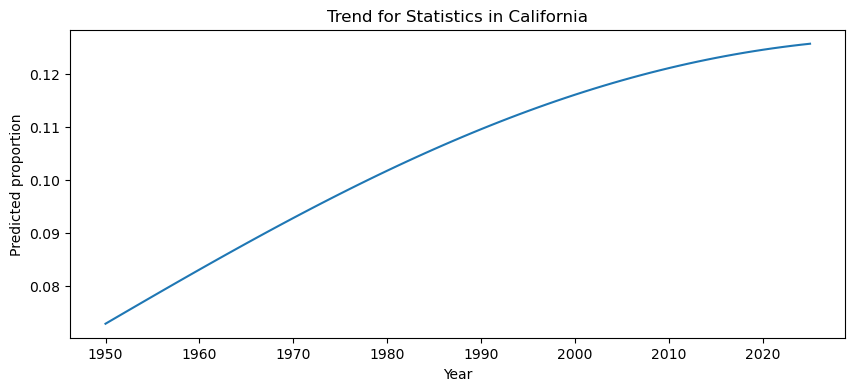

In [232]:
 

subject = 62


subject_lookup = (
    df[['subject_code', 'subject_name']]
    .dropna()
    .drop_duplicates(subset='subject_code')
    .set_index('subject_code')['subject_name']
    .to_dict()
)


subject_name = subject_lookup.get(subject, f"Subject {subject}")


import seaborn as sns
import matplotlib.pyplot as plt

state = "California"

df_hm = result[result["state"] == state]

pivot = df_hm.pivot(index="year", columns="state", values=subject)

plt.figure(figsize=(10,4))
plt.plot(df_hm["year"], df_hm[subject])
plt.title(f"Trend for {subject_name} in {state}")
plt.ylabel("Predicted proportion")
plt.xlabel("Year")
plt.show()

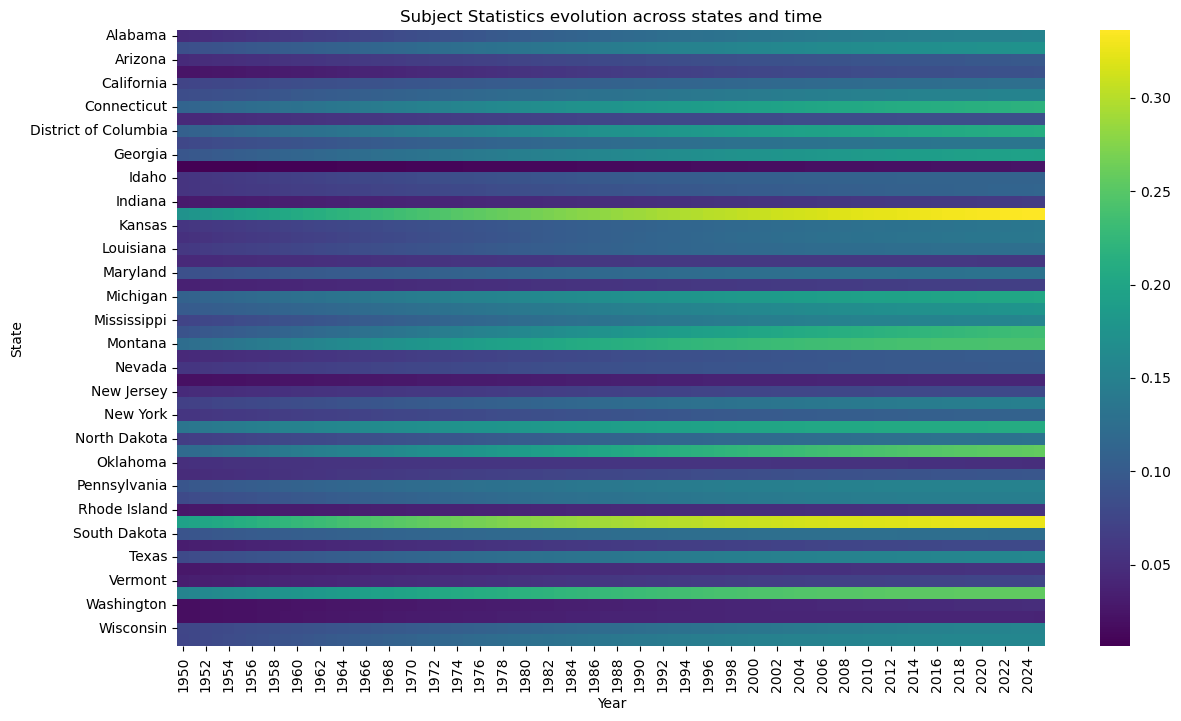

In [233]:

#heat map with states listed alphabetically
pivot = result.pivot_table(
    index="state",
    columns="year",
    values=subject
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap="viridis")
plt.title(f"Subject {subject_name} evolution across states and time")
plt.xlabel("Year")
plt.ylabel("State")
plt.show()

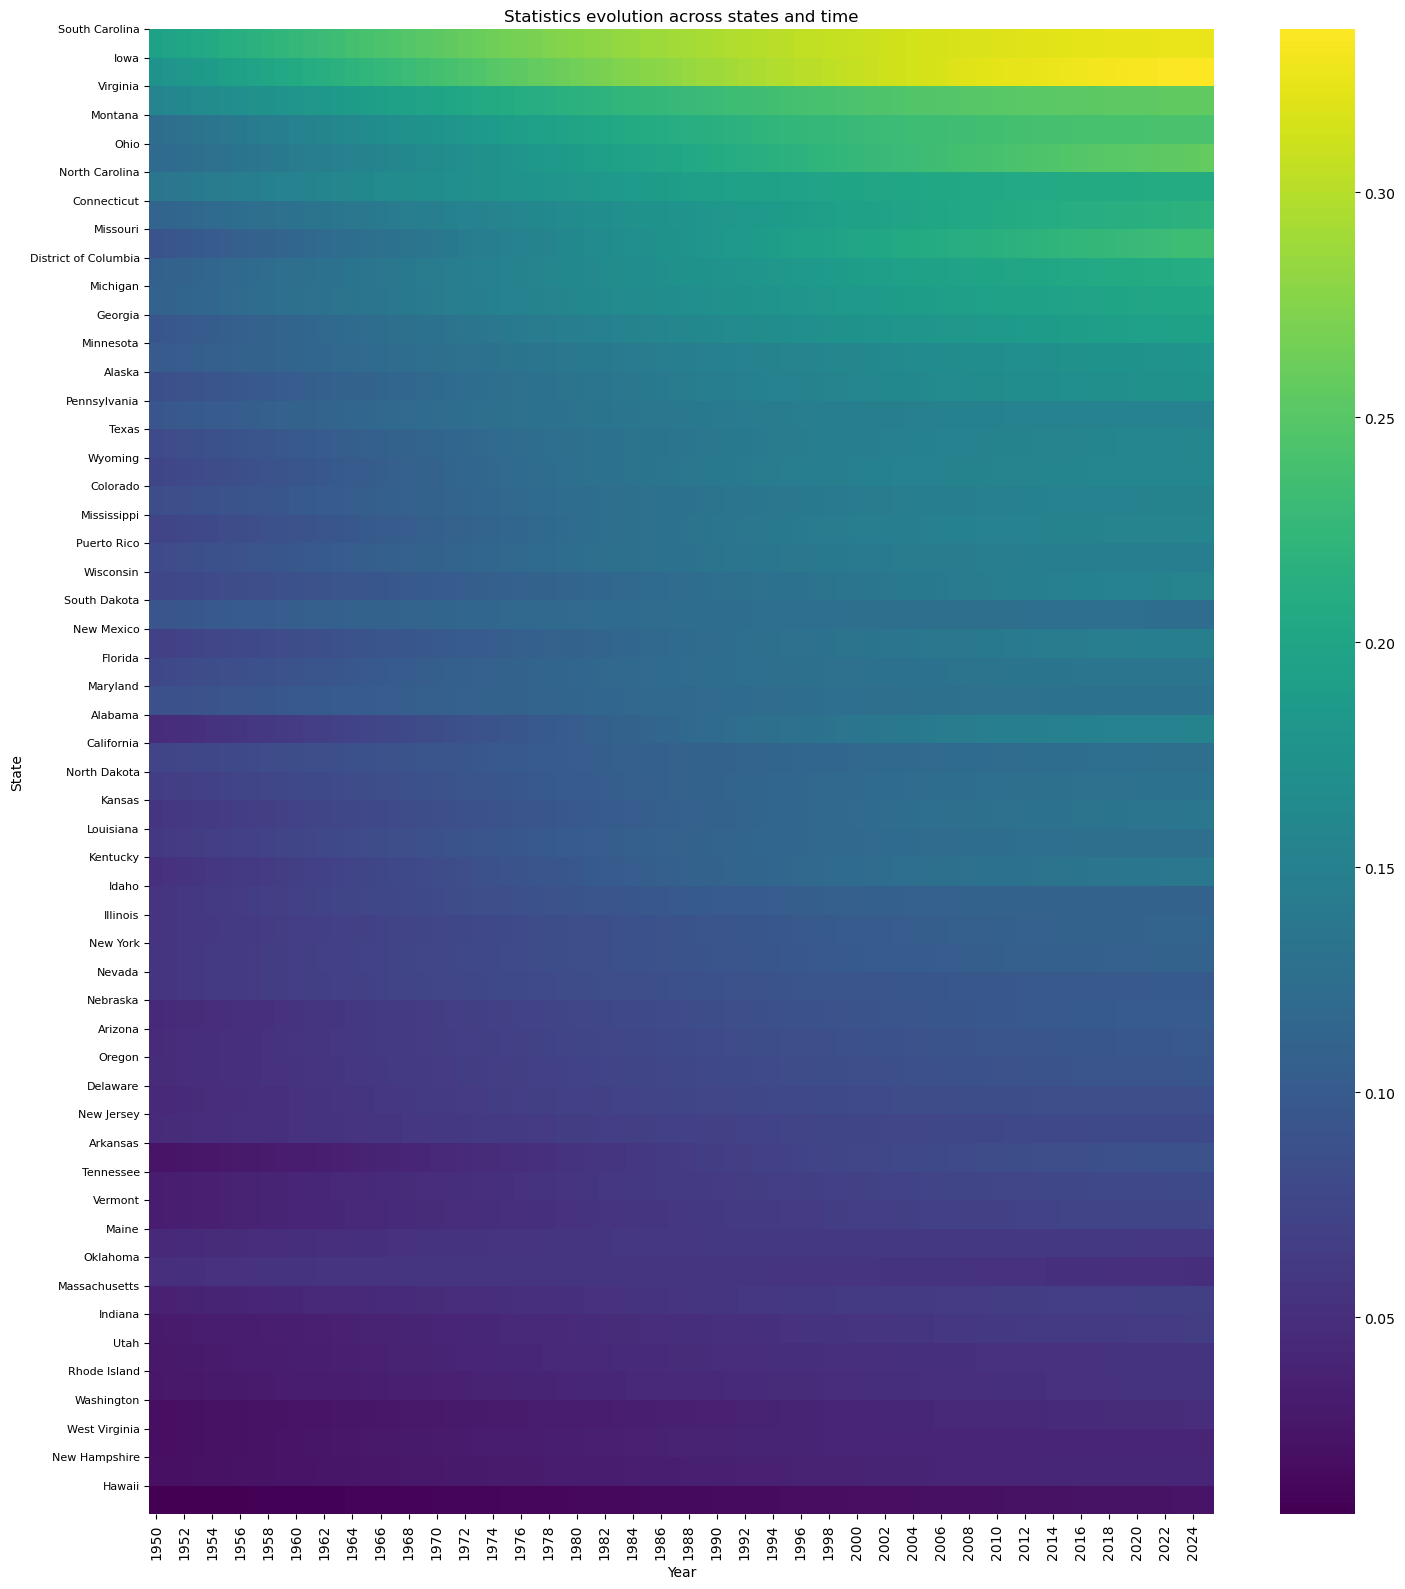

In [ ]:
#heat map with naems listed in order of brightness

plt.figure(figsize=(15, 16))

pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

ax = sns.heatmap(pivot, cmap="viridis")

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)

plt.title(f"{subject_name} evolution across states and time")
plt.xlabel("Year")
plt.ylabel("State")

plt.tight_layout()
plt.show()

   decade           state  count
0  1950.0  North Carolina      9
1  1960.0      California     30
2  1970.0        New York     44
3  1980.0   Massachusetts     43
4  1990.0      California     82


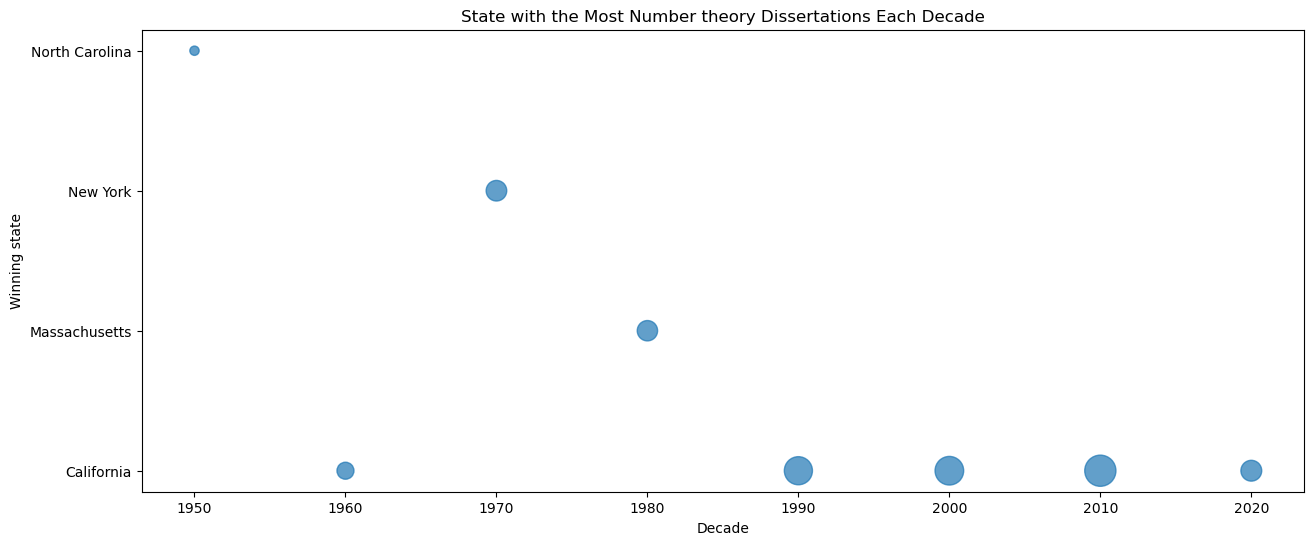

In [205]:
#repeat the analysis but with the most popular subject being counted by the total number, rather than proportion.

subject = 11

# Only years >= 1950
df2 = df[df['year'] >= 1950].copy()

df2['decade'] = (df2['year'] // 10) * 10

counts = (
    df2[df2['subject_code'] == subject]
      .groupby(['decade', 'state'])
      .size()
      .rename('count')
      .reset_index()
)

winner = (
    counts.loc[counts.groupby('decade')['count'].idxmax()]
          .sort_values('decade')
          .reset_index(drop=True)
)

print(winner.head())


states = sorted(winner['state'].unique())
state_to_num = {s: i for i, s in enumerate(states)}

winner['y'] = winner['state'].map(state_to_num)

plt.figure(figsize=(15,6))

plt.scatter(
    winner['decade'],
    winner['y'],
    s=winner['count'] * 5,   # adjust multiplier
    alpha=0.7
)

plt.yticks(range(len(states)), states)
plt.xlabel("Decade")
plt.ylabel("Winning state")
plt.title(f"State with the Most {subject_name} Dissertations Each Decade")

plt.show()



<Figure size 1400x700 with 0 Axes>

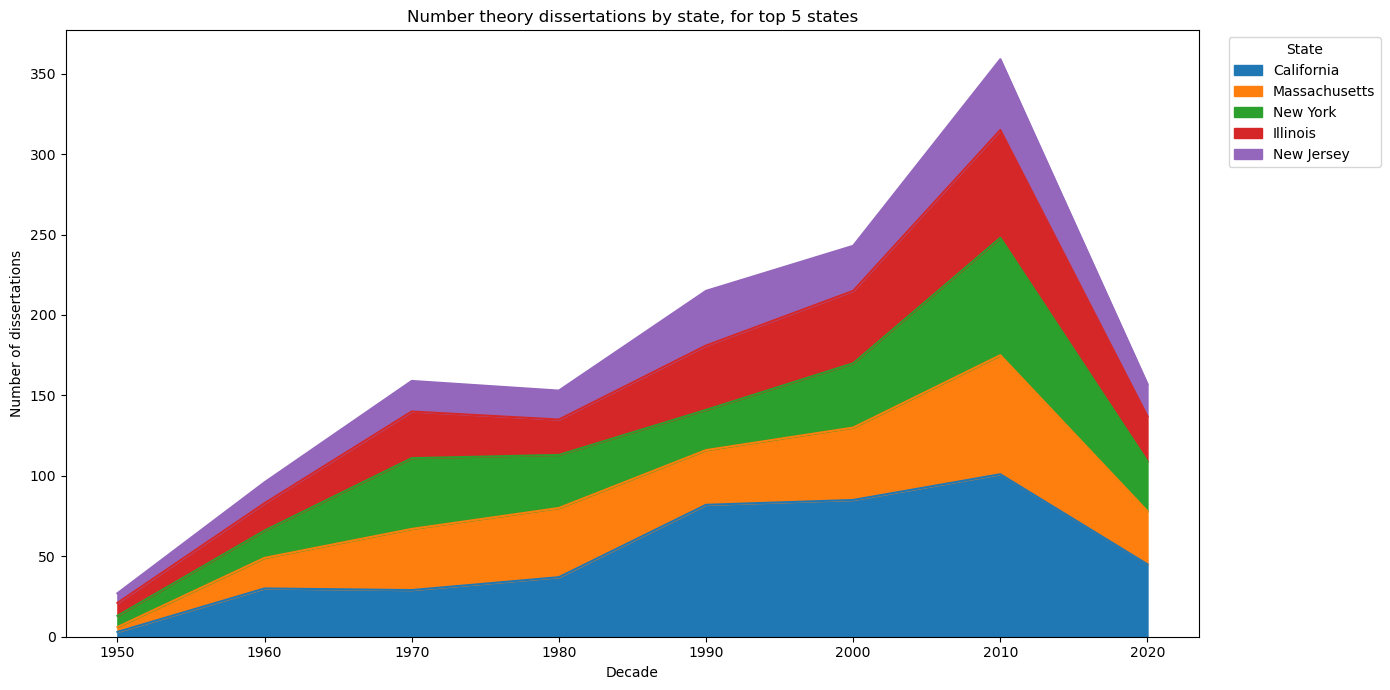

In [206]:
subject = 11

# Only years >= 1950
df2 = df[df['year'] >= 1950].copy()

# Keep only dissertations in the subject
tmp = df2[df2['subject_code'] == subject].copy()



# Create decade
tmp['decade'] = (tmp['year'] // 10) * 10

counts = (
    tmp.groupby(['decade', 'state'])
       .size()
       .unstack(fill_value=0)
)

top_states = (
    counts.sum(axis=0)
          .nlargest(5)
          .index
)

counts = counts[top_states]

plt.figure(figsize=(14,7))

counts.plot.area(figsize=(14,7))

plt.title(f"{subject_name} dissertations by state, for top 5 states")
plt.xlabel("Decade")
plt.ylabel("Number of dissertations")
plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [207]:
states = sorted(model_df["state"].unique())
years = range(1950, 2026)   

future = pd.MultiIndex.from_product(
    [states, years],
    names=["state", "year"]
).to_frame(index=False)

probs = model.predict_proba(future)

prob_df = pd.DataFrame(
    probs,
    columns=model.named_steps["clf"].classes_
)

result = pd.concat(
    [future.reset_index(drop=True), prob_df],
    axis=1
)

print(result)

        state  year         0         1         3         5         6  \
0     Alabama  1950  0.000833  0.002702  0.003091  0.020146  0.008966   
1     Alabama  1951  0.000872  0.002653  0.003135  0.021112  0.008928   
2     Alabama  1952  0.000913  0.002603  0.003179  0.022115  0.008886   
3     Alabama  1953  0.000955  0.002553  0.003222  0.023154  0.008840   
4     Alabama  1954  0.000998  0.002503  0.003263  0.024230  0.008789   
...       ...   ...       ...       ...       ...       ...       ...   
3947  Wyoming  2021  0.003428  0.000198  0.003323  0.112984  0.000677   
3948  Wyoming  2022  0.003472  0.000188  0.003262  0.114553  0.000652   
3949  Wyoming  2023  0.003516  0.000179  0.003200  0.116125  0.000628   
3950  Wyoming  2024  0.003560  0.000170  0.003140  0.117697  0.000605   
3951  Wyoming  2025  0.003604  0.000161  0.003080  0.119271  0.000583   

             8        11        12  ...        82        83        85  \
0     0.000652  0.007007  0.000268  ...  0.017011 

In [208]:

#Determines change in the predicted probability of subject over time, from the first year to the last year in the dataset

subject = 62



pivot = result.pivot(
    index="year",
    columns="state",
    values=subject
)

increase = (
    pivot.loc[pivot.index.max()] -
    pivot.loc[pivot.index.min()]
)

increase.sort_values(ascending=False)

increase.sort_values(ascending=False).head(10)

state
Iowa                    0.161300
Missouri                0.142895
Ohio                    0.138090
South Carolina          0.131202
Montana                 0.118467
Alabama                 0.107057
Connecticut             0.106597
District of Columbia    0.103469
Georgia                 0.100671
Virginia                0.100172
dtype: float64

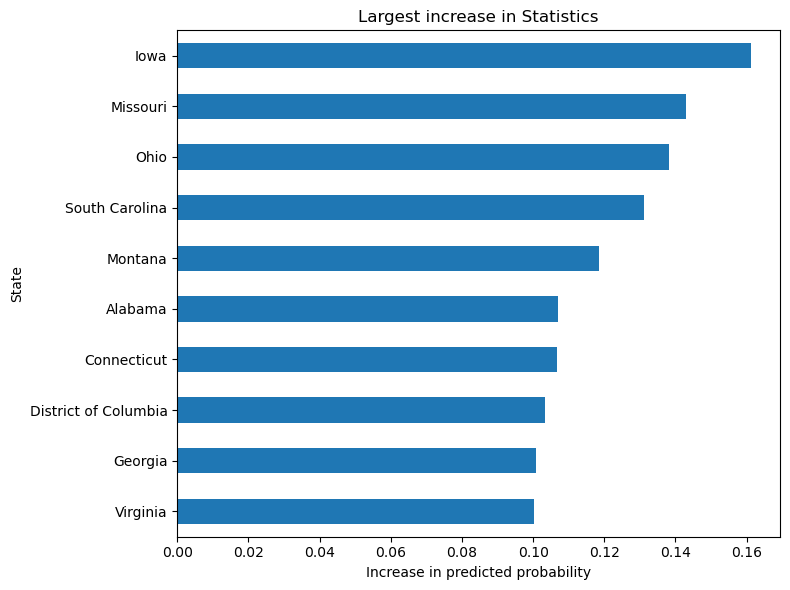

In [209]:
#plot the largest increase in predicted probability for the subject across states, from the first year to the last year in the dataset

top10 = increase.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))

top10.sort_values().plot.barh()

plt.xlabel("Increase in predicted probability")
plt.ylabel("State")
plt.title(f"Largest increase in {subject_lookup[subject]}")

plt.tight_layout()
plt.show()

In [210]:
##Determines change in the predicted probability of subject over time, using all the years in the dataset, rather than just the first and last year, by calculating the slope of the linear regression line for each state


from scipy.stats import linregress

subject = 62

pivot = result.pivot(
    index="year",
    columns="state",
    values=subject
)

slopes = {}

for state in pivot.columns:
    slope, intercept, r, p, stderr = linregress(
        pivot.index,
        pivot[state]
    )
    slopes[state] = slope

slopes = pd.Series(slopes).sort_values(ascending=False)

print(slopes.head(10))

Iowa                    0.002189
Missouri                0.001963
Ohio                    0.001889
South Carolina          0.001748
Montana                 0.001604
Alabama                 0.001536
Connecticut             0.001460
District of Columbia    0.001416
Georgia                 0.001374
Virginia                0.001350
dtype: float64


In [211]:
#determine how subjects changed in their predicted probabilities in a given state, just comparing the first and last year in the dataset, rather than using all the years in the dataset

state = "California"   

state_df = result[result["state"] == state]

first_year = state_df["year"].min()
last_year = state_df["year"].max()

first = state_df[state_df["year"] == first_year].iloc[0]
last = state_df[state_df["year"] == last_year].iloc[0]

# Subject columns are everything except state and year
subject_cols = [c for c in result.columns if c not in ["state", "year"]]

change = last[subject_cols] - first[subject_cols]

change = (
    change.rename_axis("subject_code")
          .reset_index(name="change")
)

change["subject_name"] = change["subject_code"].map(subject_lookup)

change.sort_values("change", ascending=False)

,subject_code,change,subject_name
46,68,0.189298,Computer science
44,62,0.052965,Statistics
61,94,0.03439,"Information and communication, circuits"
45,65,0.022239,Numerical analysis
3,5,0.016185,Combinatorics
...,...,...,...
15,20,-0.021936,Group theory and generalizations
52,81,-0.023107,Quantum Theory
50,78,-0.032294,"Optics, electromagnetic theory"
49,76,-0.034077,Fluid mechanics


In [212]:
#now taking all the data into account, not just the first and last year

from scipy.stats import linregress

state = "California"   

state_df = result[result["state"] == state].sort_values("year")

# All subject columns
subject_cols = [c for c in result.columns if c not in ["state", "year"]]

slopes = []

for subject in subject_cols:

    slope, intercept, r, p, stderr = linregress(
        state_df["year"],
        state_df[subject]
    )

    slopes.append({
        "subject_code": subject,
        "subject_name": subject_lookup.get(subject, "Unknown"),
        "slope": slope,
        "p_value": p,
        "r_squared": r**2
    })

slopes = pd.DataFrame(slopes)

slopes.sort_values("slope", ascending=False).head(10)

slopes["abs_slope"] = slopes["slope"].abs()


#showing which subjects had the largest absolute change in predicted probability over time, regardless of whether it was an increase or decrease
slopes.sort_values("abs_slope", ascending=False).head(10)

,subject_code,subject_name,slope,p_value,r_squared,abs_slope
46,68,Computer science,0.002566,5.902210e-102,0.998041,0.002566
58,91,"Game theory, economics, social and behavioral ...",-0.001225,9.098538e-65,0.980185,0.001225
44,62,Statistics,0.000725,5.395783e-60,0.973334,0.000725
49,76,Fluid mechanics,-0.000477,2.831079e-80,0.992450,0.000477
61,94,"Information and communication, circuits",0.000470,9.786003e-100,0.997751,0.000470
50,78,"Optics, electromagnetic theory",-0.000417,9.116984e-49,0.946389,0.000417
52,81,Quantum Theory,-0.000321,1.315055e-116,0.999213,0.000321
45,65,Numerical analysis,0.000302,7.842615e-116,0.999174,0.000302
15,20,Group theory and generalizations,-0.000292,5.513860e-60,0.973318,0.000292
2,3,Mathematical logic and foundations,-0.000262,3.115672e-108,0.998675,0.000262


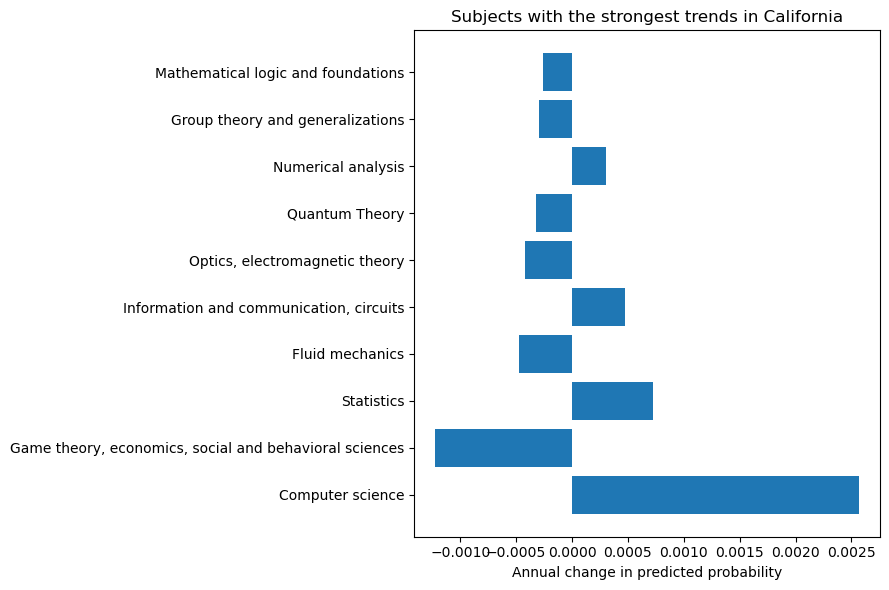

In [213]:
top10 = (
    slopes
    .sort_values("abs_slope", ascending=False)
    .head(10)
)

plt.figure(figsize=(9,6))

plt.barh(top10["subject_name"], top10["slope"])

plt.xlabel("Annual change in predicted probability")
plt.title(f"Subjects with the strongest trends in {state}")

plt.tight_layout()
plt.show()

In [214]:
# Here volatility is defined as the standard deviation of the predicted probabilities for each subject over time, for each state. This gives a measure of how much the predicted probabilities fluctuate over time. 
# Here we are considering the question of which states experienced lots of changes across many subjects. 

subject_cols = [c for c in result.columns if c not in ["state", "year"]]

volatility = []

for state in result["state"].unique():

    state_df = result[result["state"] == state]

    stds = state_df[subject_cols].std()

    volatility.append({
        "state": state,
        "average_volatility": stds.mean(),
        "maximum_volatility": stds.max(),
        "most_volatile_subject": stds.idxmax()
    })

volatility = pd.DataFrame(volatility)


volatility.sort_values("average_volatility", ascending=False)

,state,average_volatility,maximum_volatility,most_volatile_subject
3,Arkansas,0.006400,0.102026,54
0,Alabama,0.006247,0.083537,54
49,West Virginia,0.006146,0.121057,5
51,Wyoming,0.005144,0.056144,34
18,Louisiana,0.005074,0.048760,68
17,Kentucky,0.005025,0.056861,68
12,Idaho,0.004959,0.054090,68
27,Nebraska,0.004944,0.055888,68
24,Mississippi,0.004868,0.050141,5
43,Tennessee,0.004794,0.046410,68


In [215]:
# Now we consider which state had one subject that changed dramatically. Volatility is now year to year change. Note volatility in this sense is quite low. 

state_df[subject_cols].diff().abs()

volatility = []

for state in result["state"].unique():

    state_df = (
        result[result["state"] == state]
        .sort_values("year")
    )

    annual_change = (
        state_df[subject_cols]
        .diff()
        .abs()
        .mean()
        .mean()
    )

    volatility.append({
        "state": state,
        "volatility": annual_change
    })

volatility = pd.DataFrame(volatility)

volatility.sort_values("volatility", ascending=False)

,state,volatility
3,Arkansas,0.000280
49,West Virginia,0.000278
0,Alabama,0.000276
51,Wyoming,0.000231
17,Kentucky,0.000229
18,Louisiana,0.000228
12,Idaho,0.000223
24,Mississippi,0.000220
27,Nebraska,0.000220
43,Tennessee,0.000216


In [216]:
# Here we consider how states changed the distribution of their subjects. 
import numpy as np


subject_cols = [c for c in result.columns if c not in ["state", "year"]]



volatility = []

for state in result["state"].unique():

    state_df = (
        result[result["state"] == state]
        .sort_values("year")
    )

    probs = state_df[subject_cols].to_numpy()

    # Euclidean distance between consecutive years
    distances = np.sqrt(((probs[1:] - probs[:-1]) ** 2).sum(axis=1))

    volatility.append({
        "state": state,
        "average_distance": distances.mean(),
        "maximum_distance": distances.max(),
        "total_distance": distances.sum()
    })

volatility = (
    pd.DataFrame(volatility)
      .sort_values("average_distance", ascending=False)
)

print(volatility.head(10))

            state  average_distance  maximum_distance  total_distance
49  West Virginia          0.007173          0.008833        0.538003
3        Arkansas          0.006649          0.007861        0.498639
0         Alabama          0.005512          0.007132        0.413386
19          Maine          0.005187          0.006069        0.389032
51        Wyoming          0.004705          0.006499        0.352848
36       Oklahoma          0.004601          0.007533        0.345046
11         Hawaii          0.004086          0.004221        0.306453
24    Mississippi          0.004070          0.004794        0.305252
17       Kentucky          0.004025          0.005336        0.301856
48     Washington          0.003981          0.006560        0.298555


In [217]:
# Finding which subjects caused the most change in a given state. 

state = "California"

state_df = (
    result[result["state"] == state]
    .sort_values("year")
)

changes = (
    state_df[subject_cols]
    .diff()
    .abs()
    .mean()
    .sort_values(ascending=False)
)

changes = changes.rename_axis("subject_code").reset_index(name="mean_annual_change")
changes["subject_name"] = changes["subject_code"].map(subject_lookup)

print(changes.head(10))

   subject_code  mean_annual_change  \
0            68            0.002524   
1            91            0.001160   
2            62            0.000706   
3            94            0.000459   
4            76            0.000454   
5            78            0.000431   
6            81            0.000308   
7            65            0.000297   
8            20            0.000292   
9             3            0.000251   

                                        subject_name  
0                                   Computer science  
1  Game theory, economics, social and behavioral ...  
2                                         Statistics  
3            Information and communication, circuits  
4                                    Fluid mechanics  
5                     Optics, electromagnetic theory  
6                                     Quantum Theory  
7                                 Numerical analysis  
8                   Group theory and generalizations  
9                 Ma

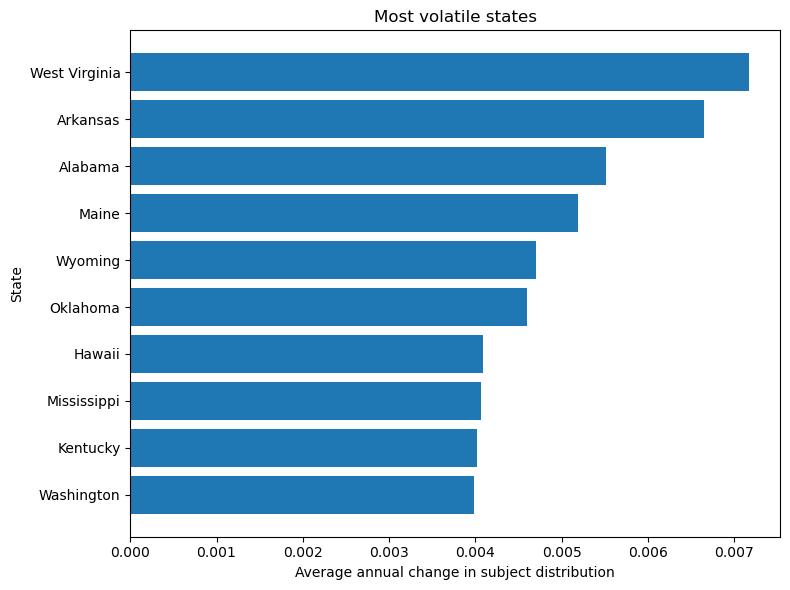

In [218]:

#graph the most volatile states, based on the average annual change in subject distribution
top10 = volatility.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["state"],
    top10["average_distance"]
)

plt.xlabel("Average annual change in subject distribution")
plt.ylabel("State")
plt.title("Most volatile states")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()